import

In [14]:
%matplotlib inline
import pandas as pd
from cd_library import draw_cd_diagram

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


caricamnto csv

In [4]:
df = pd.read_csv('csv_finale.csv')

manipolazione colonne e pulizia dati

In [5]:
df_perf = df.rename(columns={
    'algorithm': 'classifier_name',
    'dataset': 'dataset_name'
})
# 2. Definiamo le colonne su cui vogliamo calcolare media e deviazione standard
metrics = ['accuracy', 'f1_score', 'total_time_seconds', 'fit_time', 'predict_time']

# 3. Aggregazione: raggruppiamo per dataset e classificatore
# Usiamo 'agg' per calcolare sia mean che std in un colpo solo
df_grouped = df_perf.groupby(['dataset_name', 'classifier_name'])[metrics].agg(['mean', 'std']).reset_index()

# 4. Pulizia dei nomi delle colonne
# Dopo l'aggregazione le colonne sono multi-indice (es. ('accuracy', 'mean'))
# Le trasformiamo in nomi piatti come 'accuracy_mean'
df_grouped.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0]
    for col in df_grouped.columns
]

# 5. Gestione dei metadati (train_size, series_length, num_classes)
# Poiché questi non cambiano tra i seed, prendiamo semplicemente il primo valore
metadata = df_perf.groupby(['dataset_name', 'classifier_name'])[['train_size', 'series_length', 'num_classes']].first().reset_index()

# 6. Uniamo i risultati aggregati con i metadati
df_final = pd.merge(df_grouped, metadata, on=['dataset_name', 'classifier_name'])

# Arrotondiamo per rendere il CSV più leggibile (opzionale)
df_final = df_final.round(4)

In [6]:
# Creiamo la tabella pivot per l'accuratezza media
pivot_accuracy = df_final.pivot(index='dataset_name', columns='classifier_name', values='accuracy_mean')

# Stampiamola a schermo
print(pivot_accuracy)


classifier_name      Arsenal    BOSS  HIVECOTEV2  InceptionTime  RIC_RF  \
dataset_name                                                              
Chinatown             0.9825  0.9067      0.9825         0.9835  0.9776   
Crop                  0.7378  0.6645      0.7459         0.7487  0.7444   
DiatomSizeReduction   0.9739  0.9281      0.9510         0.9237  0.9205   
ElectricDevices       0.7280  0.6732         NaN         0.7033  0.7275   
FordB                 0.8111  0.8160      0.8198         0.8568  0.7617   
Fungi                 1.0000  0.9946         NaN         1.0000  0.9731   
HandOutlines          0.9396  0.9189      0.9405         0.9495  0.9270   
HouseTwenty           0.9664  0.9748      0.9748         0.9720  0.9748   
InsectEPGSmallTrain   0.9813  0.9277      0.9719         0.9424  0.8407   
ItalyPowerDemand      0.9699  0.9310      0.9699         0.9653  0.9517   
Rock                  0.9000  0.7600      0.9600         0.7800  0.9267   
SmoothSubspace        0.9

In [7]:
pivot_accuracy.to_csv('tabella_accuratezza_tesi.csv')

critical difference diagram per accuracy

In [8]:
# 1. Usa il DataFrame originale (quello con tutti i seed)
# Assicurati che abbia le colonne 'classifier_name', 'dataset_name' e 'accuracy'
df_for_plot = df_perf[['dataset_name', 'classifier_name', 'accuracy']].copy()

# 2. IMPORTANTE: HIVE-COTE ha solo 1 seed, gli altri 3.
# Il test di Wilcoxon richiede che il numero di osservazioni sia identico.
# Dobbiamo calcolare la media per dataset/algoritmo prima di passarlo al grafico
# in modo che ogni algoritmo abbia lo stesso numero di campioni (uno per dataset).
df_input_plot = df_for_plot.groupby(['dataset_name', 'classifier_name'])['accuracy'].mean().reset_index()

In [9]:
draw_cd_diagram(df_perf=df_input_plot, title='', labels=True)

['Arsenal' 'BOSS' 'HIVECOTEV2' 'InceptionTime' 'RIC_RF' 'ResNet' 'Rocket'
 'STC' 'WEASEL' 'drCIF']
Arsenal          1.0
BOSS             0.0
InceptionTime    3.0
RIC_RF           1.0
ResNet           1.0
Rocket           2.0
STC              0.0
WEASEL           1.0
drCIF            1.0
dtype: float64
STC              7.166667
BOSS             6.416667
drCIF            6.125000
WEASEL           5.708333
RIC_RF           5.291667
ResNet           4.958333
InceptionTime    3.458333
Arsenal          3.000000
Rocket           2.875000
dtype: float64
('Arsenal', 'STC', np.float64(0.0009765625), True)
('Rocket', 'STC', np.float64(0.0009765625), True)
('Arsenal', 'drCIF', np.float64(0.00244140625), False)
('BOSS', 'InceptionTime', np.float64(0.00244140625), False)
('Rocket', 'drCIF', np.float64(0.00244140625), False)
('Arsenal', 'BOSS', np.float64(0.00341796875), False)
('BOSS', 'Rocket', np.float64(0.0048828125), False)
('Arsenal', 'WEASEL', np.float64(0.005859375), False)
('Rocket', 'WEASEL

barplot per i tempi

In [10]:
# 1. Calcoliamo la media (come avevi già impostato)
df_input_plot = df_perf.groupby(['dataset_name', 'classifier_name'])['accuracy'].mean().reset_index()

# 2. Identifichiamo i dataset completi
# Contiamo quanti algoritmi ci sono in totale
total_classifiers = df_input_plot['classifier_name'].nunique()

# Troviamo i dataset che hanno un numero di righe pari al numero totale di algoritmi
dataset_counts = df_input_plot.groupby('dataset_name')['classifier_name'].count()
complete_datasets = dataset_counts[dataset_counts == total_classifiers].index.tolist()

# 3. Creiamo il DataFrame filtrato (solo i 10 dataset comuni)
df_input_filtered = df_input_plot[df_input_plot['dataset_name'].isin(complete_datasets)].copy()

print(f"Dataset originali: {len(dataset_counts)}")
print(f"Dataset dopo il filtro (escluso HC2 mancante): {len(complete_datasets)}")
print(f"Dataset esclusi: {set(dataset_counts.index) - set(complete_datasets)}")

Dataset originali: 12
Dataset dopo il filtro (escluso HC2 mancante): 10
Dataset esclusi: {'ElectricDevices', 'Fungi'}


In [11]:
# 4. Generazione del diagramma
# Cambiamo il titolo per specificare che è basato sui dataset comuni
draw_cd_diagram(
    df_perf=df_input_filtered,
    title='',
    labels=True
)

['Arsenal' 'BOSS' 'HIVECOTEV2' 'InceptionTime' 'RIC_RF' 'ResNet' 'Rocket'
 'STC' 'WEASEL' 'drCIF']
Arsenal          0.0
BOSS             0.0
HIVECOTEV2       1.0
InceptionTime    3.0
RIC_RF           0.0
ResNet           1.0
Rocket           2.0
STC              0.0
WEASEL           0.0
drCIF            1.0
dtype: float64
STC              7.90
WEASEL           7.50
BOSS             7.30
drCIF            6.85
RIC_RF           6.15
ResNet           5.70
InceptionTime    3.80
Arsenal          3.65
Rocket           3.50
HIVECOTEV2       2.65
dtype: float64
('Arsenal', 'WEASEL', np.float64(0.001953125), False)
('BOSS', 'HIVECOTEV2', np.float64(0.001953125), False)
('HIVECOTEV2', 'STC', np.float64(0.001953125), False)
('HIVECOTEV2', 'WEASEL', np.float64(0.001953125), False)
('Rocket', 'WEASEL', np.float64(0.001953125), False)
('Arsenal', 'STC', np.float64(0.00390625), False)
('HIVECOTEV2', 'RIC_RF', np.float64(0.00390625), False)
('Rocket', 'STC', np.float64(0.00390625), False)
('HIVECOTEV2'

In [12]:
# --- PREPARAZIONE DATI (comune a entrambi) ---
df_by_dataset = df_perf.groupby(['dataset_name', 'classifier_name'])[['fit_time', 'predict_time']].mean().reset_index()
df_agg = df_by_dataset.groupby('classifier_name')[['fit_time', 'predict_time']].sum().reset_index()
df_agg['total'] = df_agg['fit_time'] + df_agg['predict_time']
df_agg = df_agg.sort_values('total', ascending=False)

def plot_and_save(log_scale=False, filename='grafico.pdf'):
    plt.figure(figsize=(10, 7))

    # Disegno le barre
    plt.bar(df_agg['classifier_name'], df_agg['fit_time'], label='Fit Time (Training)', color='#4c72b0')
    plt.bar(df_agg['classifier_name'], df_agg['predict_time'], bottom=df_agg['fit_time'],
            label='Predict Time (Inference)', color='#dd8452')

    # Configurazione scala e scritte
    if log_scale:
        plt.yscale('log')
        plt.ylabel('Tempo Totale (secondi) - Scala Logaritmica')
        plt.title('Efficienza Computazionale (Log Scale)')
        plt.grid(axis='y', linestyle='-', alpha=0.3, which="major")
    else:
        plt.ylabel('Tempo Totale (secondi)')
        plt.title('Efficienza Computazionale (Linear Scale)')
        plt.grid(axis='y', linestyle='-', alpha=0.3)

    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Salvataggio
    plt.savefig(filename, bbox_inches='tight')
    print(f"File salvato: {filename}")
    plt.close() # Fondamentale per non sovrapporre i grafici in memoria

# 1. Salva il grafico Lineare
plot_and_save(log_scale=False, filename='confronto_tempi_lineare.pdf')

# 2. Salva il grafico Logaritmico
plot_and_save(log_scale=True, filename='confronto_tempi_logaritmico.pdf')

File salvato: confronto_tempi_lineare.pdf
File salvato: confronto_tempi_logaritmico.pdf


File salvato correttamente con font aumentati: confronto_tempi_colorato.pdf


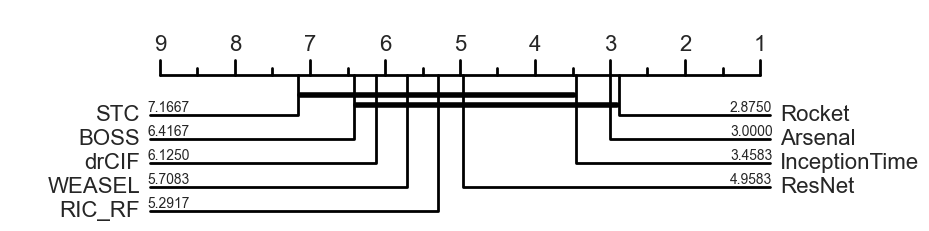

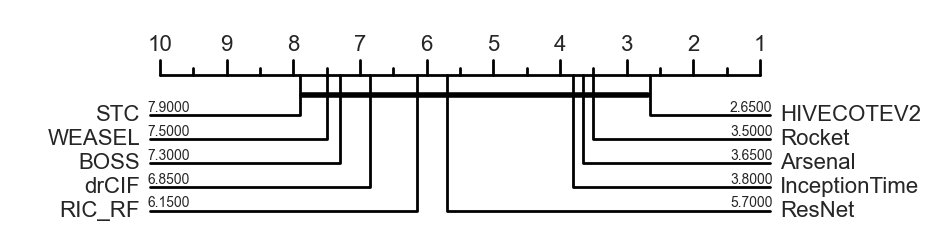

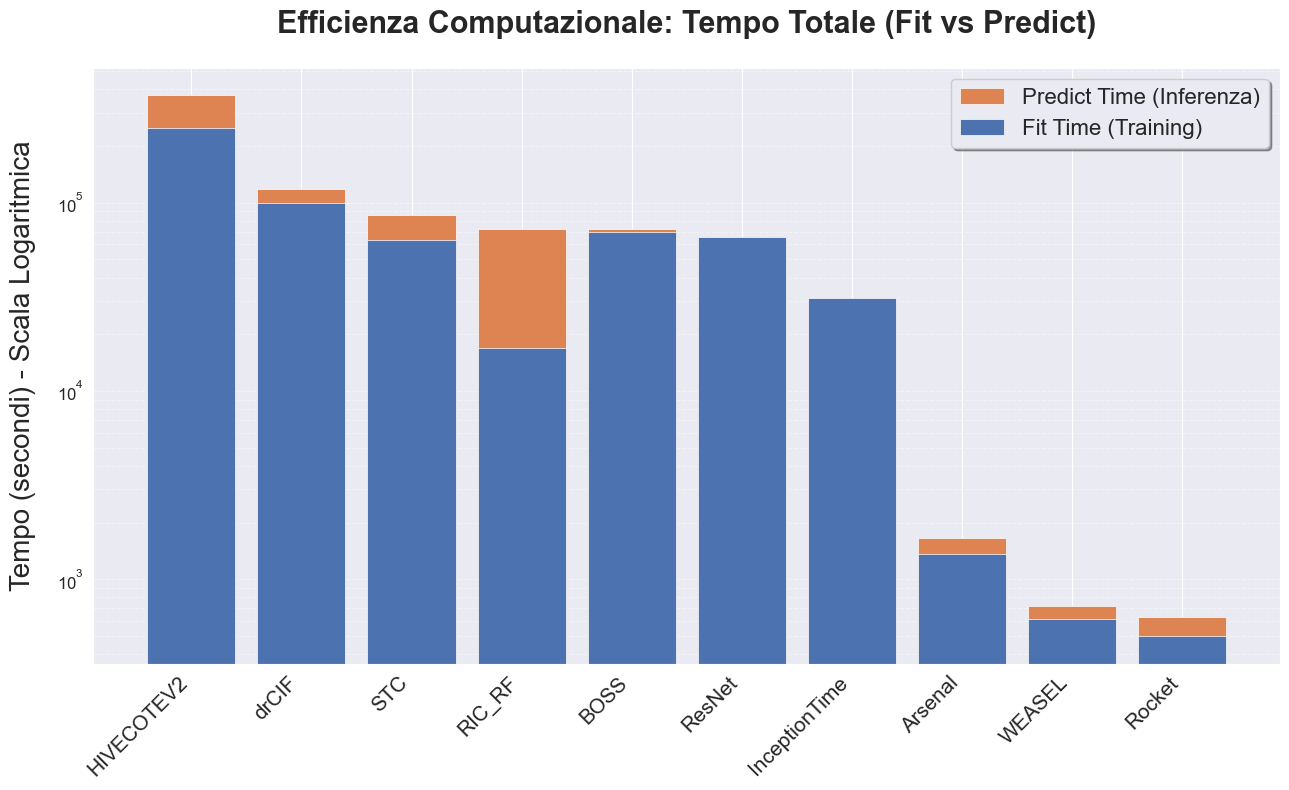

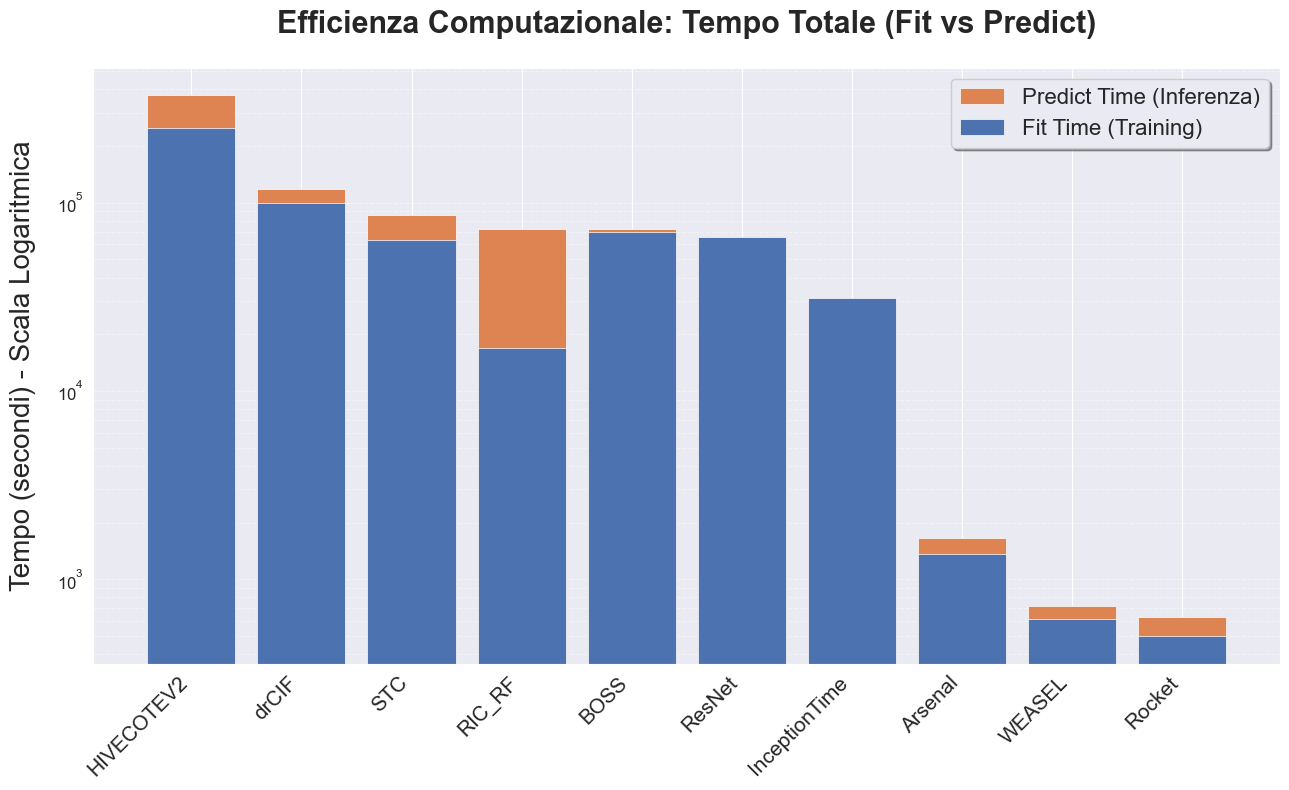

In [15]:

def plot_log_total_with_perc(df_input, filename='confronto_tempi_colorato.pdf'):
    # Prepariamo i dati
    df = df_input.copy()
    df['total'] = df['fit_time'] + df['predict_time']
    df = df.sort_values('total', ascending=False).reset_index(drop=True)

    # Aumentiamo leggermente l'altezza della figura per far stare i testi grandi
    plt.figure(figsize=(13, 8))

    # 1. Sfondo: Predict Time (Arancione)
    plt.bar(df['classifier_name'], df['total'], color='#dd8452',
            label='Predict Time (Inferenza)', edgecolor='white', linewidth=0.5)

    # 2. Primo piano: Fit Time (Blu)
    plt.bar(df['classifier_name'], df['fit_time'], color='#4c72b0',
            label='Fit Time (Training)', edgecolor='white', linewidth=0.5)

    # --- CONFIGURAZIONE TESTI (AUMENTATI) ---
    plt.yscale('log')

    # Asse Y: Etichetta grande
    plt.ylabel('Tempo (secondi) - Scala Logaritmica', fontsize=20, labelpad=15)

    # Titolo: Molto visibile
    plt.title('Efficienza Computazionale: Tempo Totale (Fit vs Predict)', fontsize=22, pad=25, fontweight='bold')

    # Tick degli assi (Numeri e Nomi Algoritmi)
    plt.yticks(fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=15) # Nomi algoritmi più grandi

    # Legenda: Ingrandita e posizionata meglio
    plt.legend(fontsize=16, loc='upper right', frameon=True, shadow=True)

    # Griglia
    plt.grid(axis='y', which='both', linestyle='--', alpha=0.4)

    plt.tight_layout()

    # Salvataggio ad alta risoluzione
    plt.savefig(filename, bbox_inches='tight', dpi=300)
    print(f"File salvato correttamente con font aumentati: {filename}")
    plt.show()

# Esegui il test
plot_log_total_with_perc(df_agg)

Grafico salvato con sfondo bianco: confronto_tempi_affiancati_bianco.pdf


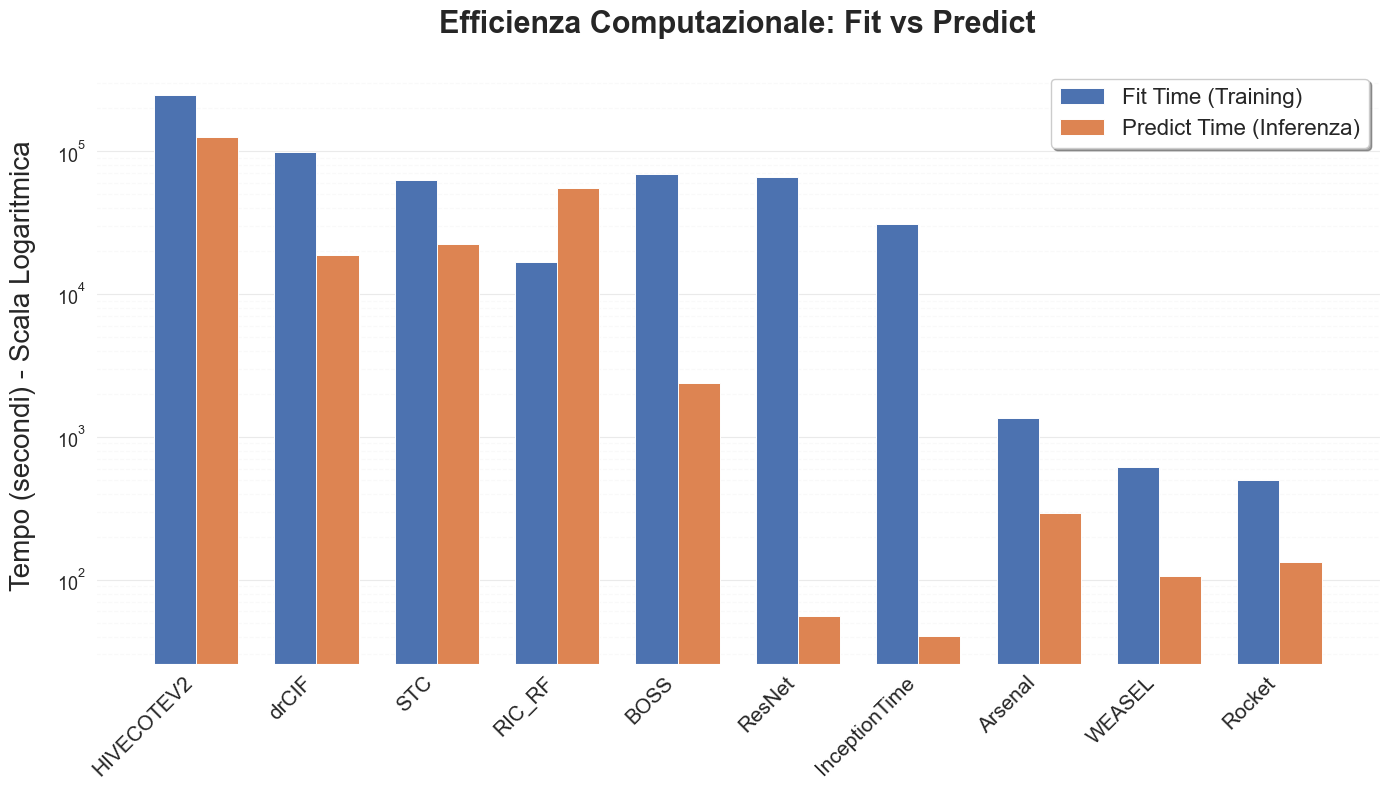

In [20]:
def plot_grouped_log_times_white(df_input, filename='confronto_tempi_affiancati_bianco.pdf'):
    # Prepariamo i dati (logica invariata)
    df = df_input.copy()
    df['total'] = df['fit_time'] + df['predict_time']
    df = df.sort_values('total', ascending=False).reset_index(drop=True)

    # --- MODIFICA 1: Imposta lo sfondo della FIGURE a bianco ---
    # `facecolor='white'` rende bianca l'area esterna agli assi
    fig = plt.figure(figsize=(14, 8), facecolor='white')
    ax = fig.add_subplot(111) # Creiamo gli assi esplicitamente per controllarli meglio

    # --- MODIFICA 2: Imposta lo sfondo degli AXES a bianco ---
    # `ax.set_facecolor('white')` rende bianca l'area interna al grafico
    ax.set_facecolor('white')

    # --- LOGICA PER BARRE AFFIANCATE (invariata, ma usando `ax`) ---
    x = np.arange(len(df['classifier_name']))
    width = 0.35

    # Barre Fit (Blu)
    ax.bar(x - width/2, df['fit_time'], width, color='#4c72b0',
            label='Fit Time (Training)', edgecolor='white', linewidth=0.7)

    # Barre Predict (Arancione)
    ax.bar(x + width/2, df['predict_time'], width, color='#dd8452',
            label='Predict Time (Inferenza)', edgecolor='white', linewidth=0.7)

    # --- CONFIGURAZIONE ASSI E SCALA (usando `ax`) ---
    ax.set_yscale('log')

    # Titoli e Etichette
    ax.set_title('Efficienza Computazionale: Fit vs Predict', fontsize=22, pad=25, fontweight='bold')
    ax.set_ylabel('Tempo (secondi) - Scala Logaritmica', fontsize=20, labelpad=15)

    # Configurazione asse X: nomi algoritmi al centro delle due barre
    ax.set_xticks(x)
    ax.set_xticklabels(df['classifier_name'], rotation=45, ha='right', fontsize=15)
    ax.tick_params(axis='y', labelsize=13) # Y tick fontsize

    # Legenda (con sfondo bianco esplicito per sicurezza)
    ax.legend(fontsize=16, loc='upper right', frameon=True, shadow=True, facecolor='white')

    # Griglia: più visibile su sfondo bianco
    ax.grid(axis='y', which='major', linestyle='-', alpha=0.6, color='#dddddd')
    ax.grid(axis='y', which='minor', linestyle='--', alpha=0.3, color='#eeeeee')

    plt.tight_layout()

    # --- SALVATAGGIO ---
    # Per rendere trasparente il PDF finale fuori dagli assi, usa `transparent=True`
    # Ma `facecolor='white'` nella figure lo renderà bianco nel PDF.
    plt.savefig(filename, bbox_inches='tight', dpi=300, facecolor=fig.get_facecolor(), transparent=False)
    print(f"Grafico salvato con sfondo bianco: {filename}")
    plt.show()

# Esecuzione
plot_grouped_log_times_white(df_agg)

In [107]:
import os
# Carica il file grezzo
path = "../ucr/Fungi/Fungi_TRAIN.tsv"

if os.path.exists(path):
    df_TRAIN = pd.read_csv(path, sep='\t', header=None)
    y = df_TRAIN.iloc[:, 0].values
    X_raw = df_TRAIN.iloc[:, 1:].values
    print(f"Dataset caricato correttamente!")
    print(f"Dimensioni: {X_raw.shape[0]} serie, lunghezza {X_raw.shape[1]}")
else:
    print(f"Errore: il file non è stato trovato al percorso {os.path.abspath(path)}")

Dataset caricato correttamente!
Dimensioni: 18 serie, lunghezza 201


In [108]:
print(f"Valori nulli nel dataset grezzo: {df_TRAIN.isnull().sum().sum()}")

Valori nulli nel dataset grezzo: 0


In [109]:
path = "../ucr/Fungi/Fungi_TEST.tsv"

if os.path.exists(path):
    df_TEST = pd.read_csv(path, sep='\t', header=None)
    y = df_TEST.iloc[:, 0].values
    X_raw = df_TEST.iloc[:, 1:].values
    print(f"Dataset caricato correttamente!")
    print(f"Dimensioni: {X_raw.shape[0]} serie, lunghezza {X_raw.shape[1]}")
else:
    print(f"Errore: il file non è stato trovato al percorso {os.path.abspath(path)}")

Dataset caricato correttamente!
Dimensioni: 186 serie, lunghezza 201


In [110]:
print(f"Valori nulli nel dataset grezzo: {df_TEST.isnull().sum().sum()}")

Valori nulli nel dataset grezzo: 0


In [111]:
def test_your_normalization(X_raw, name="Dataset"):
    X_norm = np.copy(X_raw).astype(float)
    count_flat = 0
    count_nan_after = 0

    for i in range(len(X_norm)):
        # Calcoliamo media e std come faceva il tuo script
        m = np.mean(X_norm[i])
        s = np.std(X_norm[i])

        if s == 0:
            count_flat += 1
            X_norm[i] = X_norm[i] - m  # Diventa una serie di soli ZERI
        else:
            X_norm[i] = (X_norm[i] - m) / s

        # Controllo se dopo l'operazione sono apparsi NaN
        if np.isnan(X_norm[i]).any():
            count_nan_after += 1

    print(f"--- Risultati Normalizzazione su {name} ---")
    print(f"Serie totali: {len(X_norm)}")
    print(f"Serie piatte (s=0) trovate: {count_flat}")
    print(f"Serie che contengono NaN dopo norm: {count_nan_after}")
    print(f"Valore MAX assoluto dopo norm: {np.max(np.abs(X_norm))}")
    print("-" * 40)
    return X_norm

# Applichiamo ai tuoi dati caricati
X_train_norm = test_your_normalization(df_TRAIN, "TRAIN") # Usa il nome della variabile che hai usato per il training
X_test_norm = test_your_normalization(df_TEST, "TEST")

--- Risultati Normalizzazione su TRAIN ---
Serie totali: 18
Serie piatte (s=0) trovate: 0
Serie che contengono NaN dopo norm: 0
Valore MAX assoluto dopo norm: 5.680697874278669
----------------------------------------
--- Risultati Normalizzazione su TEST ---
Serie totali: 186
Serie piatte (s=0) trovate: 0
Serie che contengono NaN dopo norm: 0
Valore MAX assoluto dopo norm: 5.951756839439322
----------------------------------------


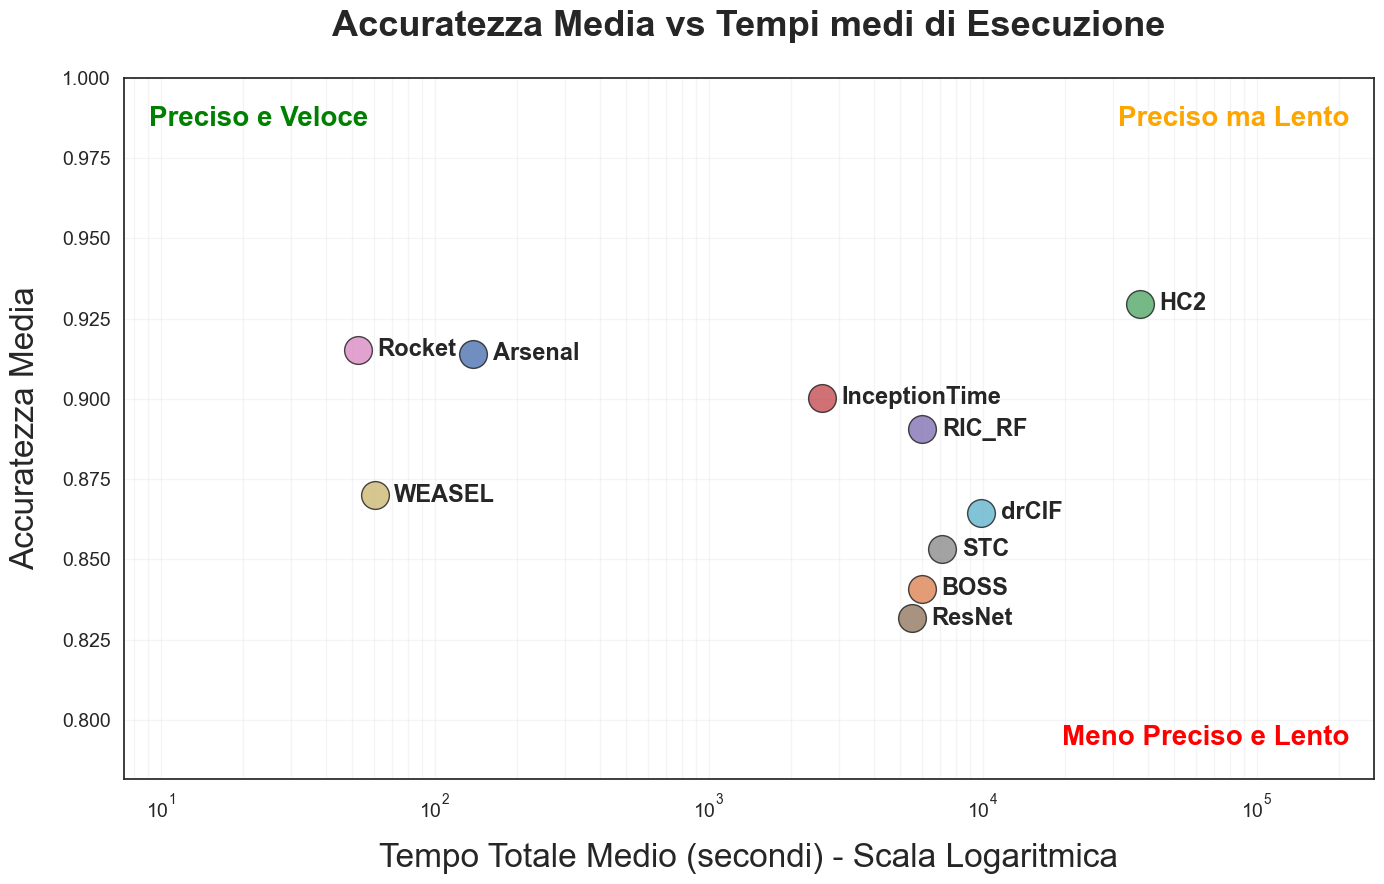

In [145]:
# 1. Preparazione dati
df_by_algo = df_perf.groupby(['dataset_name', 'classifier_name'])[['accuracy', 'total_time_seconds']].mean().reset_index()
df_final_avg = df_by_algo.groupby('classifier_name')[['accuracy', 'total_time_seconds']].mean().reset_index()

# Ridenominazione
name_mapping = {'HIVECOTEV2': 'HC2', 'InceptionTime': 'InceptionTime', 'Rocket': 'Rocket'}
df_final_avg['classifier_name'] = df_final_avg['classifier_name'].replace(name_mapping)

# 1. Preparazione dati (Assicurati che df_final_avg sia già calcolato)
plt.figure(figsize=(14, 9)) # Leggermente più grande per ospitare i testi generosi

for i, row in df_final_avg.iterrows():
    # Aumentata la dimensione del punto (s=400) per bilanciare il testo grande
    plt.scatter(row['total_time_seconds'], row['accuracy'], s=400, alpha=0.8, edgecolors='k', zorder=3)

    # Nomi algoritmi accanto ai punti (Fontsize 15)
    plt.annotate(row['classifier_name'],
                 xy=(row['total_time_seconds'], row['accuracy']),
                 xytext=(15, 0),
                 textcoords="offset points",
                 fontsize=17,
                 fontweight='bold',
                 va='center')

# 3. Scala Logaritmica per l'asse X
plt.xscale('log')

# 4. LIMITE ASSE Y
# Alzato a 1.0 per non tagliare i modelli top performer
plt.ylim(df_final_avg['accuracy'].min() - 0.05, 1.0)

# 5. Annotazioni negli angoli (Fontsize 14)
ax = plt.gca()
ax.text(0.02, 0.96, 'Preciso e Veloce', transform=ax.transAxes, fontsize=20, color='green', fontweight='bold', va='top')
ax.text(0.98, 0.96, 'Preciso ma Lento', transform=ax.transAxes, fontsize=20, color='orange', fontweight='bold', va='top', ha='right')
ax.text(0.98, 0.04, 'Meno Preciso e Lento', transform=ax.transAxes, fontsize=20, color='red', fontweight='bold', va='bottom', ha='right')

# 6. Abbellimenti (Fontsize 14 e 16 per il titolo)
plt.xlabel('Tempo Totale Medio (secondi) - Scala Logaritmica', fontsize=24, labelpad=15)
plt.ylabel('Accuratezza Media', fontsize=24, labelpad=15)
plt.title('Accuratezza Media vs Tempi medi di Esecuzione', fontsize=26, pad=30, fontweight='bold')

# Tick degli assi (i numeri 0.7, 0.8, 10^1, ecc.)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Margini per l'asse X (tempo) per non far finire le scritte fuori dal bordo
plt.margins(x=0.3)

plt.grid(True, which="both", ls="-", alpha=0.2, zorder=0)

# 7. Salvataggio ad alta risoluzione
plt.tight_layout()
plt.savefig('scatter_accuracy_vs_time.pdf', bbox_inches='tight', dpi=300)
plt.show()

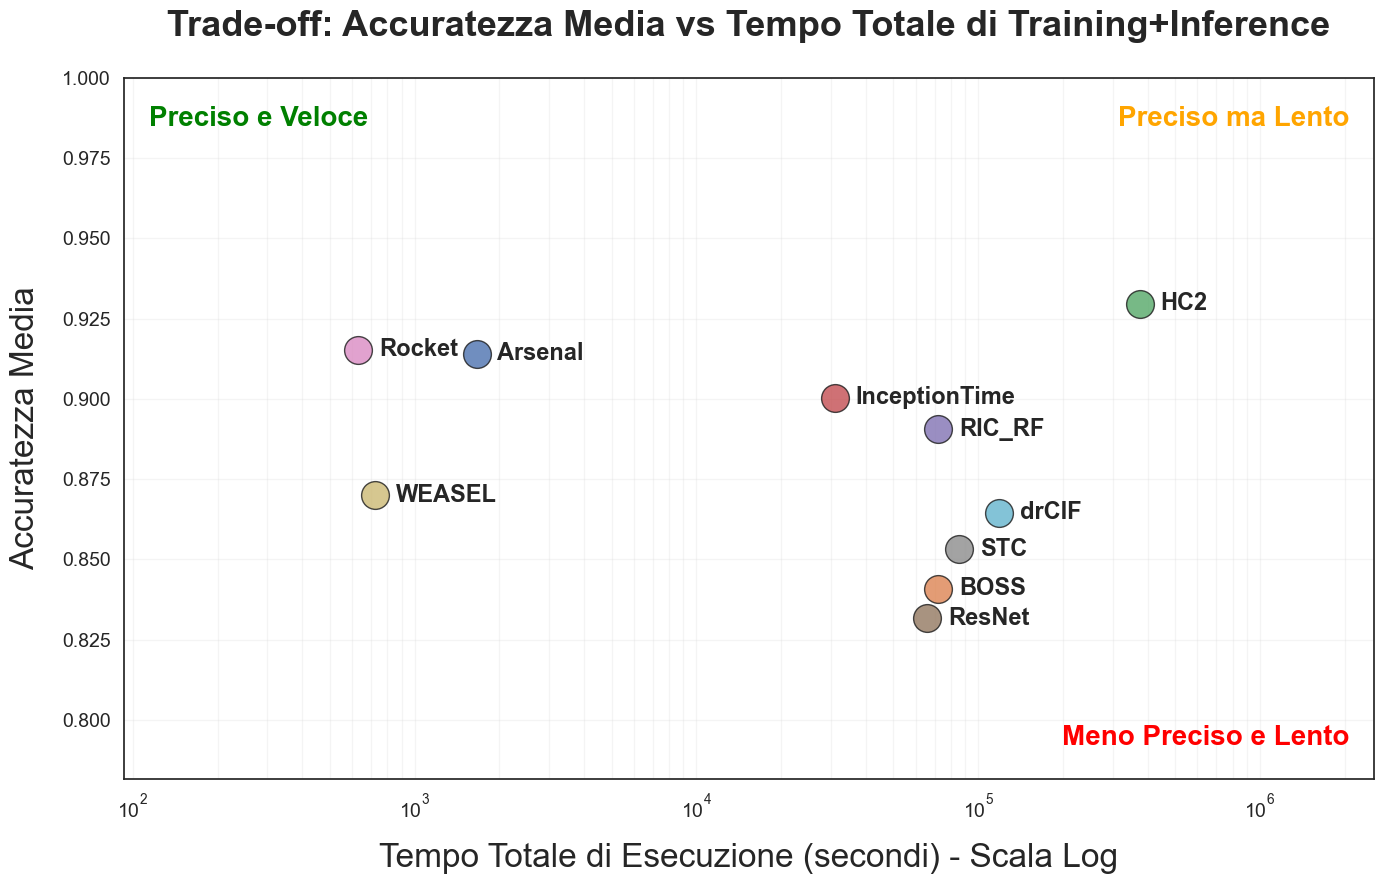

Grafico generato con coerenza scientifica: Accuratezza Media vs Somma dei Tempi.


In [207]:
# 1. PREPARAZIONE DATI (Aggregazione Ibrida)
# Passaggio A: Media sui seed per ogni dataset (pulisce i dati ma mantiene il tempo singolo)
df_by_dataset = df_perf.groupby(['dataset_name', 'classifier_name']).agg({
    'accuracy': 'mean',
    'total_time_seconds': 'mean'
}).reset_index()

# Passaggio B: Accuratezza MEDIA globale vs Tempo TOTALE (Somma di tutti i dataset)
df_final_avg = df_by_dataset.groupby('classifier_name').agg({
    'accuracy': 'mean',
    'total_time_seconds': 'sum'
}).reset_index()

# Ridenominazione per il grafico
name_mapping = {
    'HIVECOTEV2': 'HC2',
    'InceptionTime': 'InceptionTime',
    'Rocket': 'Rocket',
    'ARSENAL': 'Arsenal',
    'STC': 'STC',
    'DrCIF': 'DrCIF'
}
df_final_avg['classifier_name'] = df_final_avg['classifier_name'].replace(name_mapping)

# 2. CREAZIONE FIGURA
plt.figure(figsize=(14, 9))

for i, row in df_final_avg.iterrows():
    # Disegno del punto
    plt.scatter(row['total_time_seconds'], row['accuracy'], s=400, alpha=0.8, edgecolors='k', zorder=3)

    # Nomi algoritmi accanto ai punti
    plt.annotate(row['classifier_name'],
                 xy=(row['total_time_seconds'], row['accuracy']),
                 xytext=(15, 0),
                 textcoords="offset points",
                 fontsize=17,
                 fontweight='bold',
                 va='center')

# 3. SCALA LOGARITMICA (Cruciale per i tempi TSC)
plt.xscale('log')

# 4. LIMITE ASSE Y (Per non tagliare il top della classifica)
plt.ylim(df_final_avg['accuracy'].min() - 0.05, 1.0)

# 5. ANNOTAZIONI STRATEGICHE (Trade-off)
ax = plt.gca()
ax.text(0.02, 0.96, 'Preciso e Veloce', transform=ax.transAxes, fontsize=20, color='green', fontweight='bold', va='top')
ax.text(0.98, 0.96, 'Preciso ma Lento', transform=ax.transAxes, fontsize=20, color='orange', fontweight='bold', va='top', ha='right')
ax.text(0.98, 0.04, 'Meno Preciso e Lento', transform=ax.transAxes, fontsize=20, color='red', fontweight='bold', va='bottom', ha='right')

# 6. ABBELLIMENTI E ETICHETTE
# Aggiornato il titolo e la X per specificare che è il Tempo Totale (Somma)
plt.xlabel('Tempo Totale di Esecuzione (secondi) - Scala Log', fontsize=24, labelpad=15)
plt.ylabel('Accuratezza Media', fontsize=24, labelpad=15)
plt.title('Trade-off: Accuratezza Media vs Tempo Totale di Training+Inference', fontsize=26, pad=30, fontweight='bold')

# Tick degli assi
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Margini per l'asse X (tempo) per non far finire le scritte fuori dal bordo
plt.margins(x=0.3)

plt.grid(True, which="both", ls="-", alpha=0.2, zorder=0)

# 7. SALVATAGGIO
plt.tight_layout()
plt.savefig('scatter_accuracy_vs_total_time.pdf', bbox_inches='tight', dpi=300)
plt.show()

print("Grafico generato con coerenza scientifica: Accuratezza Media vs Somma dei Tempi.")

In [113]:
print(df_final_avg)

  classifier_name  accuracy  total_time_seconds
0         Arsenal  0.914018          138.322106
1            BOSS  0.840925         6009.007975
2             HC2  0.929623        37384.567396
3   InceptionTime  0.900263         2584.703810
4          RIC_RF  0.890487         6022.404110
5          ResNet  0.831611         5506.628636
6          Rocket  0.915306           52.540286
7             STC  0.853145         7131.174047
8          WEASEL  0.869909           60.322647
9           drCIF  0.864577         9874.174068


In [114]:
# Ottieni la lista unica di tutti gli algoritmi presenti nel tuo DF
all_algos = sorted(df_final['classifier_name'].unique())

# Genera una palette fissa (usa 'husl' o 'Set1' per colori ben distinti)
unique_colors = sns.color_palette("husl", len(all_algos))

# Crea il dizionario magico: {'NomeAlgo': (R, G, B)}
algo_palette = dict(zip(all_algos, unique_colors))

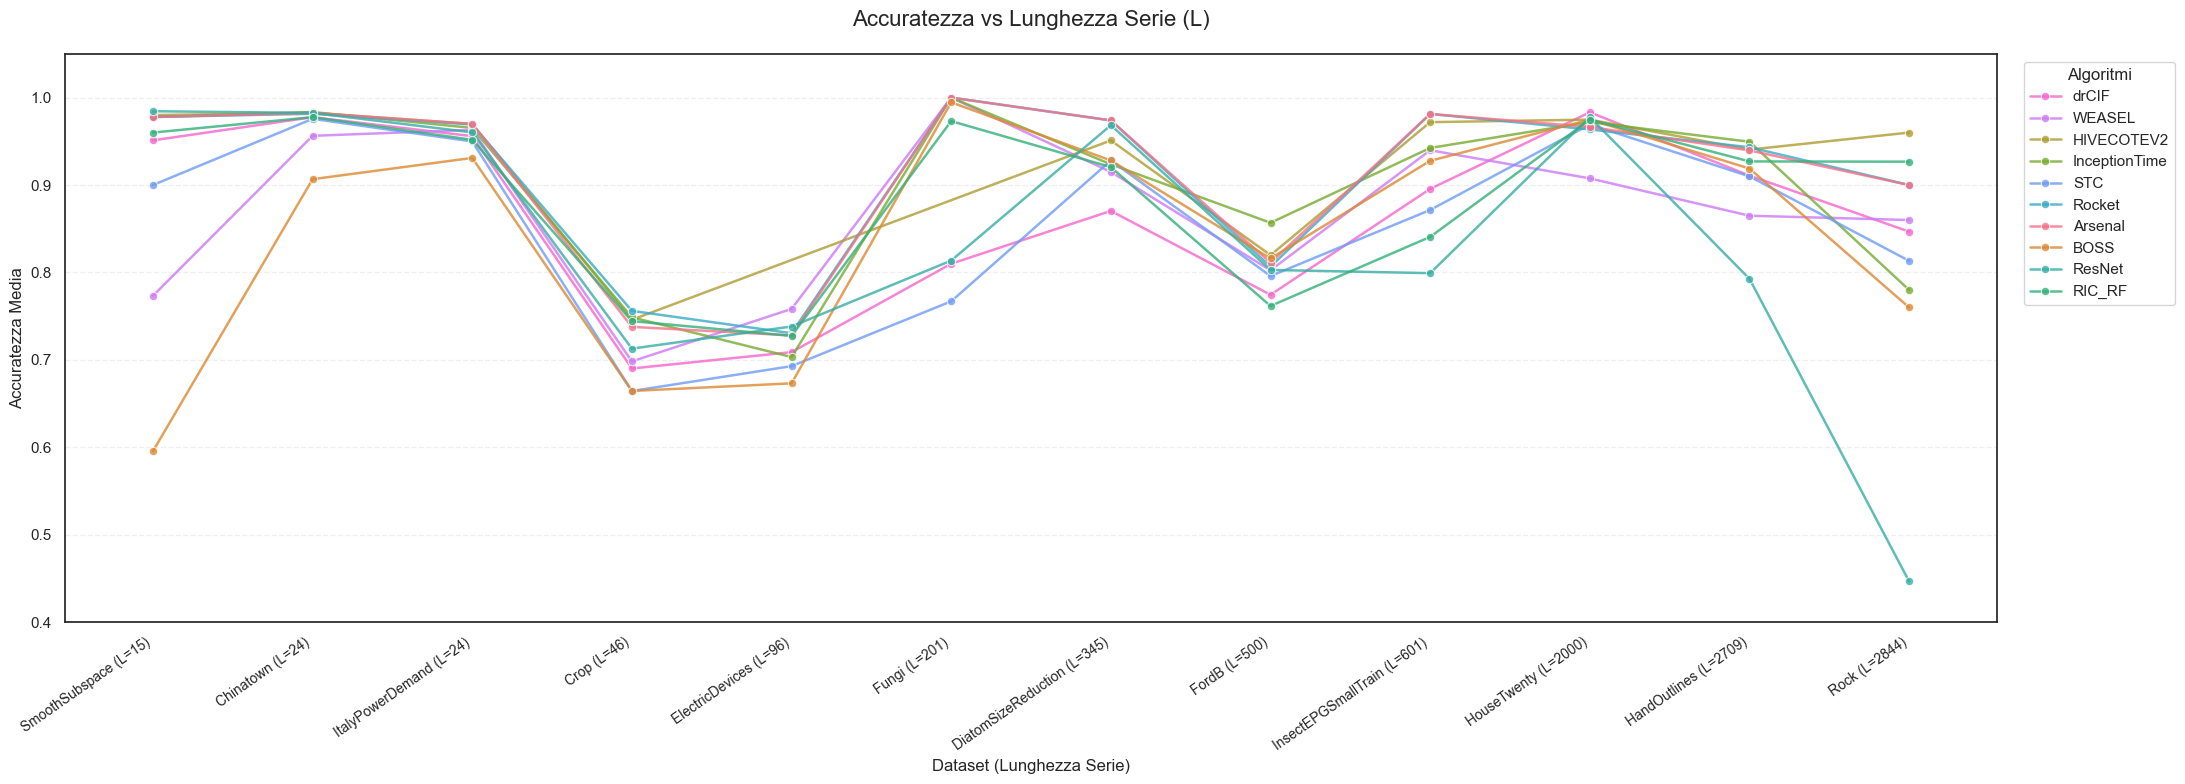

In [115]:
# --- GRAFICO 1: LUNGHEZZA SERIE ---
# 1. Ordinamento
df_len = df_final.sort_values('series_length')

# 2. Creazione etichetta con L
df_len['dataset_label'] = df_len.apply(
    lambda row: f"{row['dataset_name']} (L={int(row['series_length'])})", axis=1
)

plt.figure(figsize=(22, 8))

# 3. Plot
sns.lineplot(data=df_len, x='dataset_label', y='accuracy_mean',
             hue='classifier_name', palette=algo_palette,
             marker='o', markersize=6, linewidth=1.8, alpha=0.8)

# 4. Estetica: Inclinazione 45° e allineamento a destra
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.title('Accuratezza vs Lunghezza Serie (L)', fontsize=16, pad=20)
plt.xlabel('Dataset (Lunghezza Serie)', fontsize=12)
plt.ylabel('Accuratezza Media', fontsize=12)
plt.ylim(0.4, 1.05)
plt.legend(title="Algoritmi", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, axis='y', ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

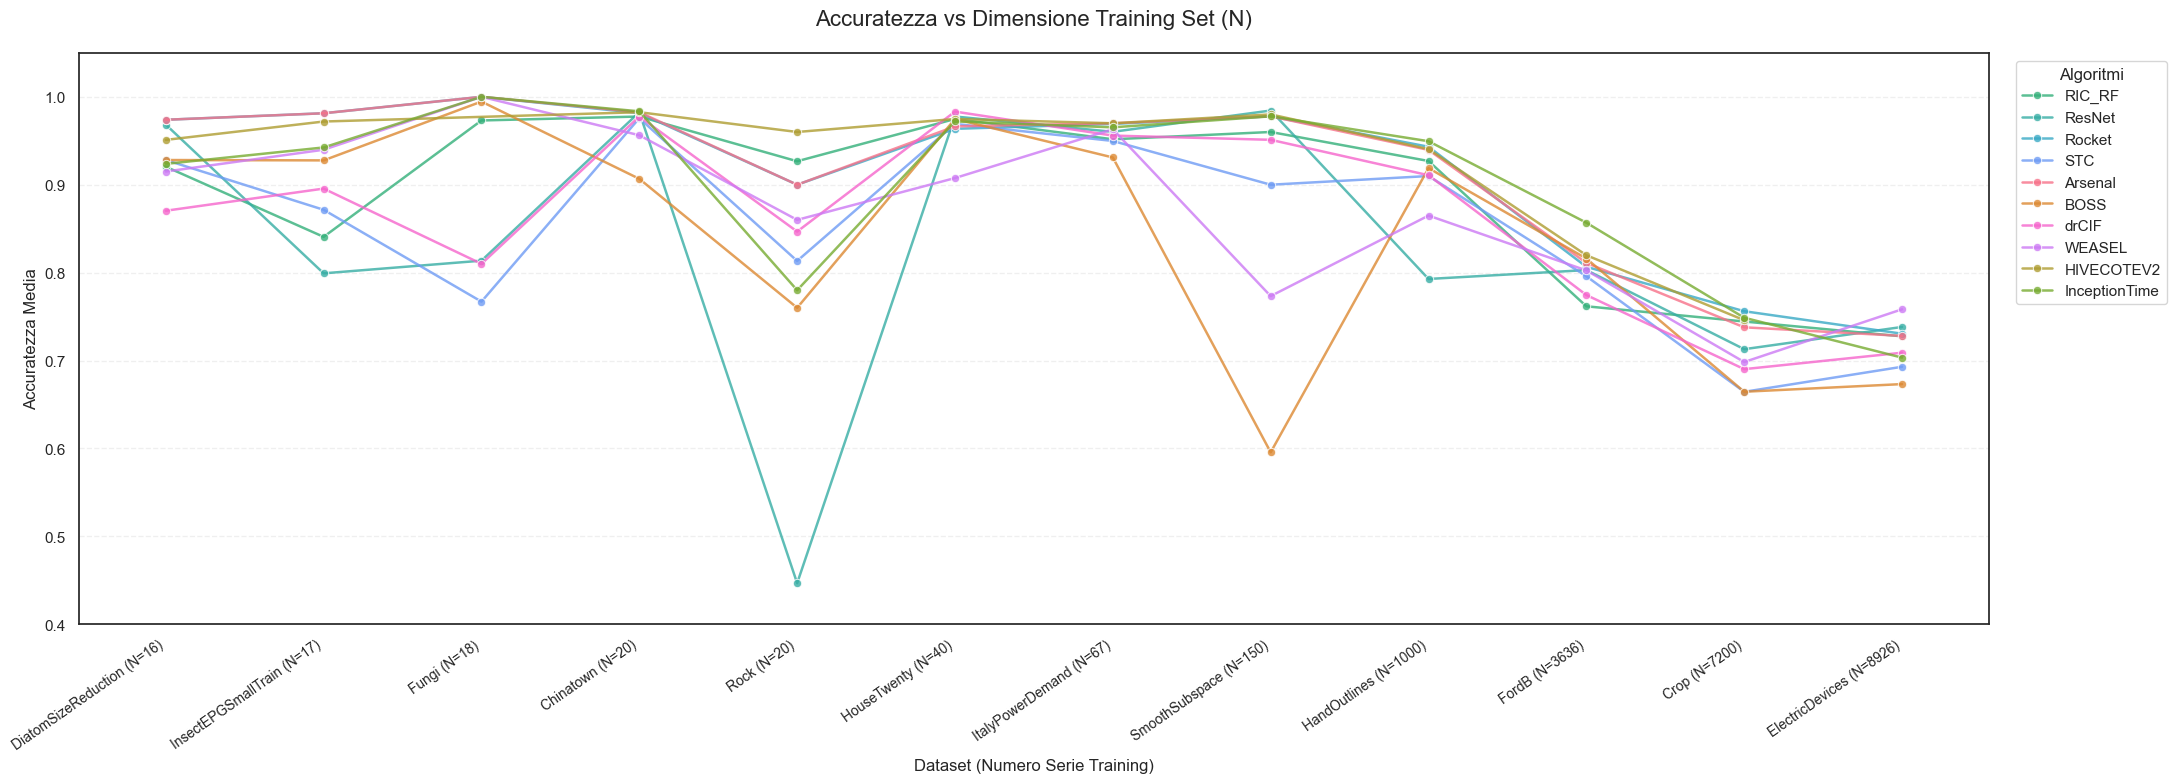

In [116]:
# --- GRAFICO 2: DIMENSIONE TRAINING ---
# 1. Ordinamento (per train_size)
df_size = df_final.sort_values('train_size')

# 2. Creazione etichetta con N
df_size['dataset_label'] = df_size.apply(
    lambda row: f"{row['dataset_name']} (N={int(row['train_size'])})", axis=1
)

plt.figure(figsize=(22, 8))

# 3. Plot (stessa palette unificata)
sns.lineplot(data=df_size, x='dataset_label', y='accuracy_mean',
             hue='classifier_name', palette=algo_palette,
             marker='o', markersize=6, linewidth=1.8, alpha=0.8)

# 4. Estetica: Inclinazione 45° e allineamento a destra
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.title('Accuratezza vs Dimensione Training Set (N)', fontsize=16, pad=20)
plt.xlabel('Dataset (Numero Serie Training)', fontsize=12)
plt.ylabel('Accuratezza Media', fontsize=12)
plt.ylim(0.4, 1.05)
plt.legend(title="Algoritmi", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, axis='y', ls='--', alpha=0.3)

plt.tight_layout()
plt.show()

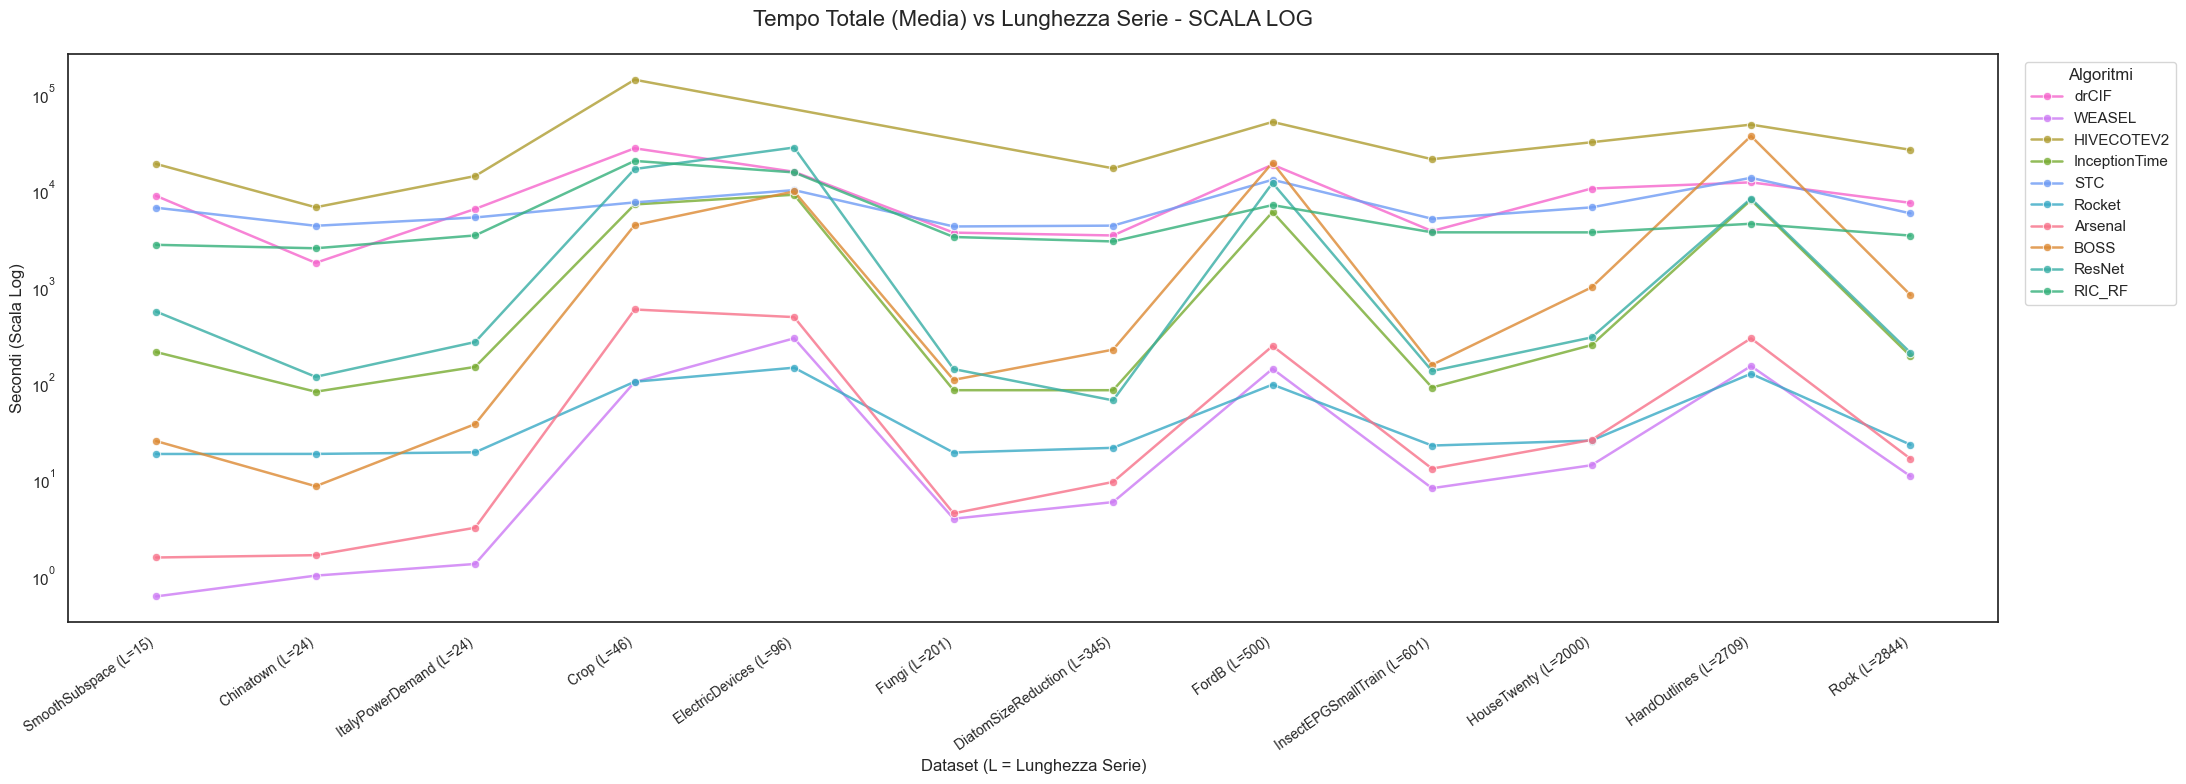

In [117]:
# --- GRAFICO 3: TOTAL TIME vs LUNGHEZZA SERIE (LOG SCALE, NO GRID) ---
df_time_len = df_final.sort_values('series_length')

df_time_len['dataset_label'] = df_time_len.apply(
    lambda row: f"{row['dataset_name']} (L={int(row['series_length'])})", axis=1
)

plt.figure(figsize=(22, 8))

sns.lineplot(data=df_time_len, x='dataset_label', y='total_time_seconds_mean',
             hue='classifier_name', palette=algo_palette,
             marker='o', markersize=6, linewidth=1.8, alpha=0.8)

plt.yscale('log')

# Rimuoviamo la griglia
plt.grid(False)

plt.xticks(rotation=35, ha='right', fontsize=10)
plt.title('Tempo Totale (Media) vs Lunghezza Serie - SCALA LOG', fontsize=16, pad=20)
plt.xlabel('Dataset (L = Lunghezza Serie)', fontsize=12)
plt.ylabel('Secondi (Scala Log)', fontsize=12)

plt.legend(title="Algoritmi", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

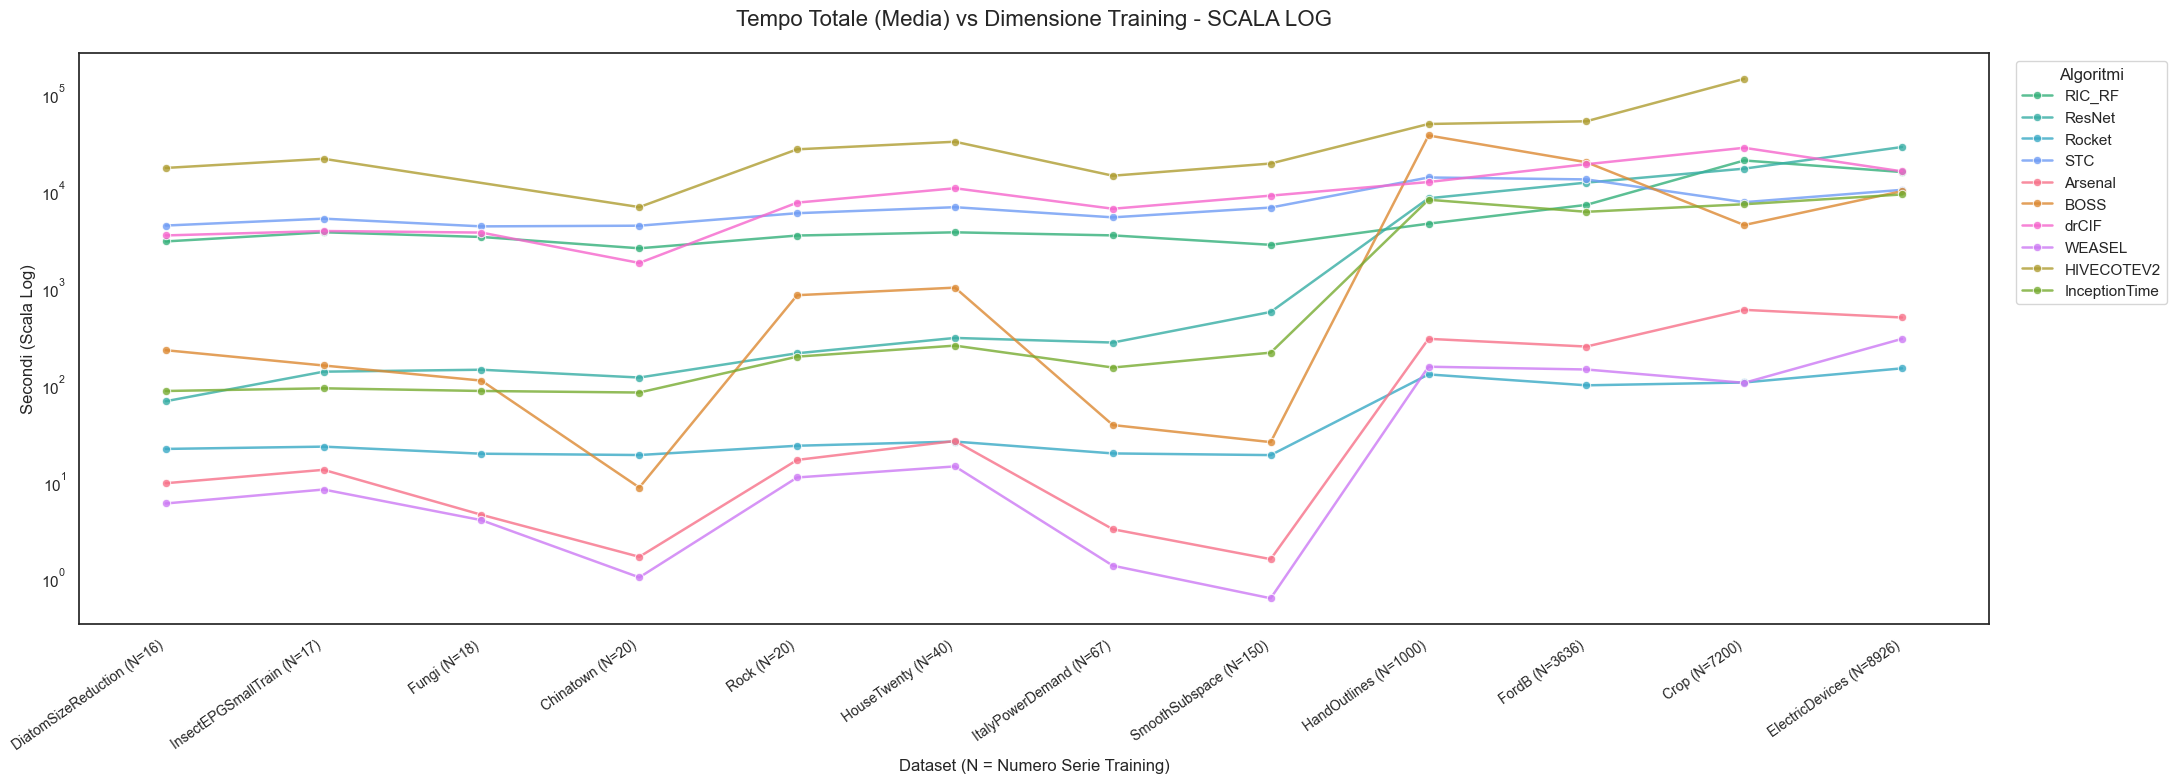

In [118]:
# --- GRAFICO 4: TOTAL TIME vs DIMENSIONE TRAINING (LOG SCALE, NO GRID) ---
df_time_size = df_final.sort_values('train_size')

df_time_size['dataset_label'] = df_time_size.apply(
    lambda row: f"{row['dataset_name']} (N={int(row['train_size'])})", axis=1
)

plt.figure(figsize=(22, 8))

sns.lineplot(data=df_time_size, x='dataset_label', y='total_time_seconds_mean',
             hue='classifier_name', palette=algo_palette,
             marker='o', markersize=6, linewidth=1.8, alpha=0.8)

plt.yscale('log')

# Rimuoviamo la griglia
plt.grid(False)

plt.xticks(rotation=35, ha='right', fontsize=10)
plt.title('Tempo Totale (Media) vs Dimensione Training - SCALA LOG', fontsize=16, pad=20)
plt.xlabel('Dataset (N = Numero Serie Training)', fontsize=12)
plt.ylabel('Secondi (Scala Log)', fontsize=12)

plt.legend(title="Algoritmi", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

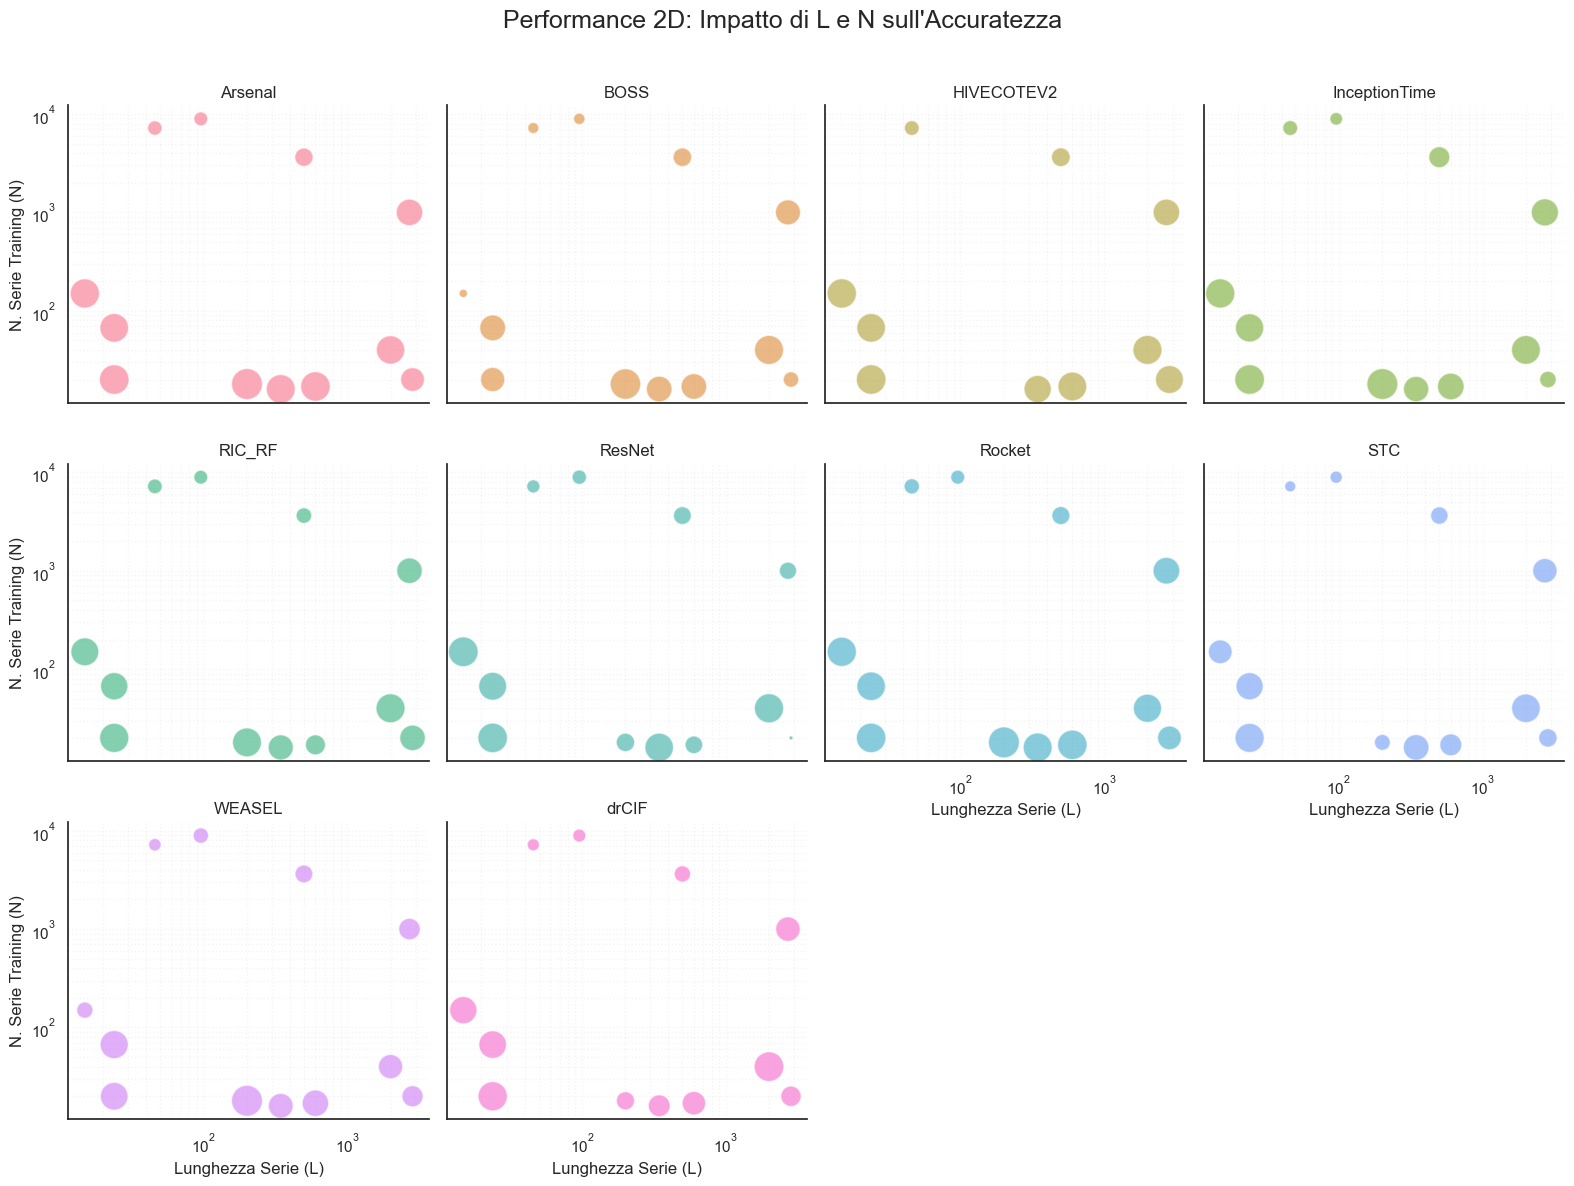

In [119]:
# 1. Configurazione dello stile
sns.set_theme(style="white")

# 2. Creazione del FacetGrid: un grafico per ogni algoritmo
# 'col_wrap=4' significa che mette 4 grafici per riga
g = sns.FacetGrid(df_final, col="classifier_name", hue="classifier_name",
                  palette=algo_palette, col_wrap=4, height=4)

# 3. Mappatura dei dati
# Usiamo la scala logaritmica per gli assi perché L e N variano di molto
def bubble_plot(x, y, size, **kwargs):
    # s è la dimensione della bolla, la moltiplichiamo per 200 per renderla visibile
    plt.scatter(x, y, s=size**5 * 500, alpha=0.6, edgecolors='w', **kwargs)

g.map(bubble_plot, "series_length", "train_size", "accuracy_mean")

# 4. Impostazioni assi logaritmici
for ax in g.axes.flatten():
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls=":", alpha=0.2)

# 5. Titoli e label
g.set_axis_labels("Lunghezza Serie (L)", "N. Serie Training (N)")
g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Performance 2D: Impatto di L e N sull\'Accuratezza', fontsize=18)

plt.show()

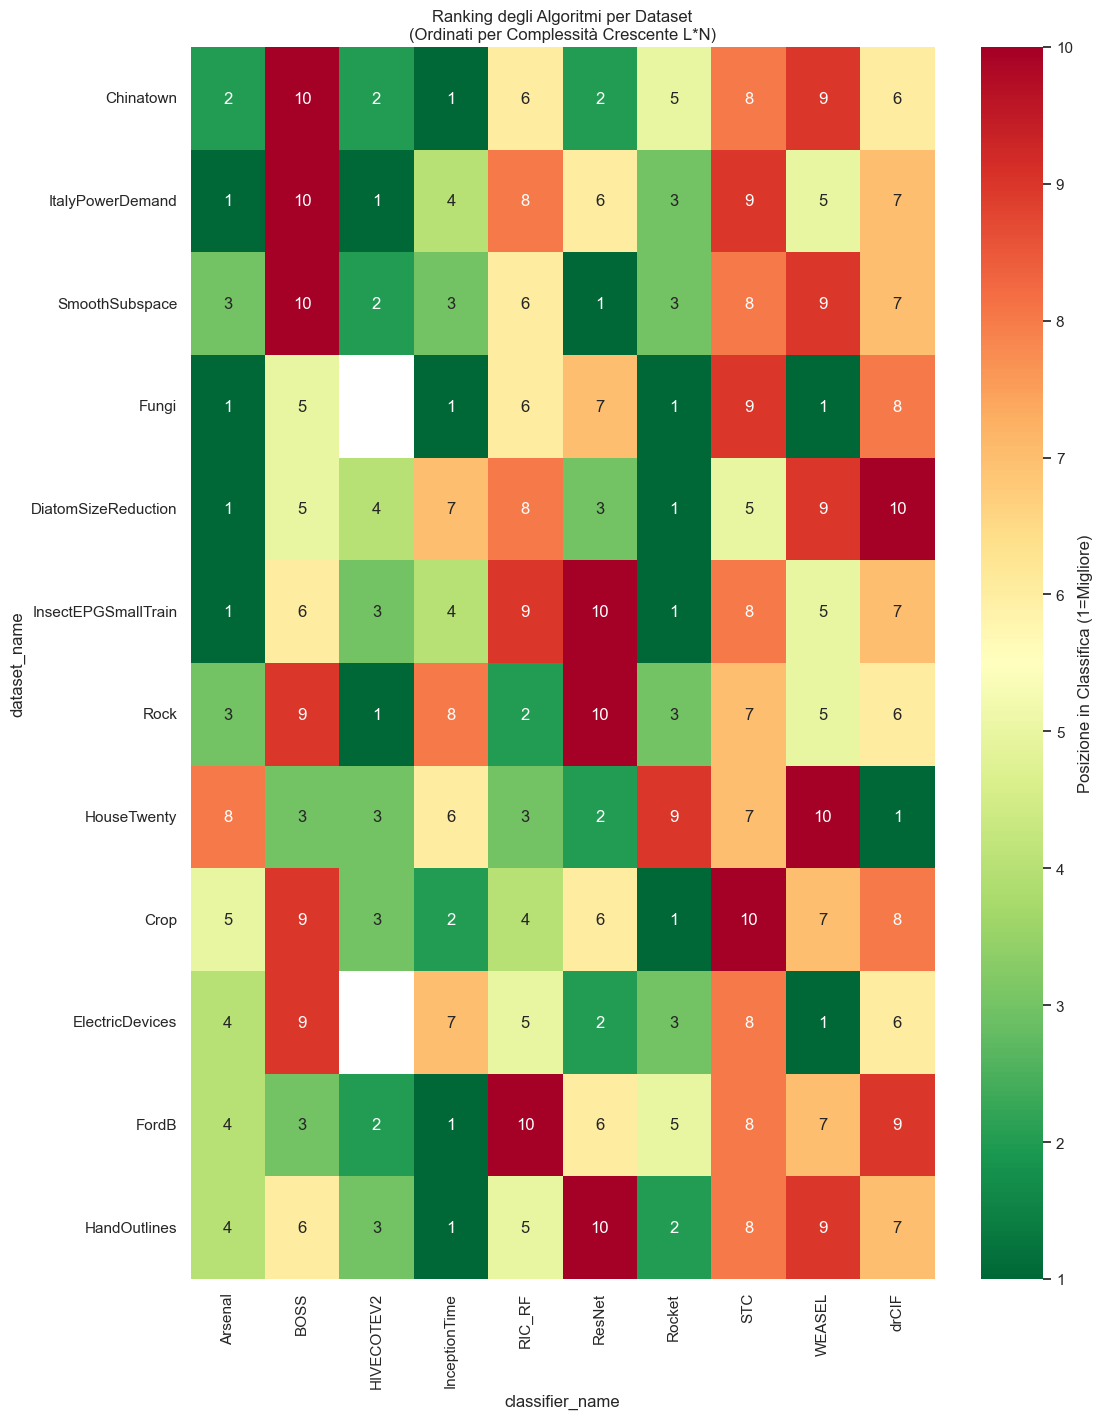

In [120]:
# Creiamo una matrice dove ogni cella è il rango dell'algoritmo per quel dataset
df_rank = df_final.copy()
df_rank['rank'] = df_rank.groupby('dataset_name')['accuracy_mean'].rank(ascending=False, method='min')

# Trasformiamo in matrice per la heatmap
pivot_rank = df_rank.pivot(index='dataset_name', columns='classifier_name', values='rank')

# Ordiniamo i dataset per complessità (L * N) per dare un senso all'asse verticale
df_metadata = df_final.groupby('dataset_name')[['series_length', 'train_size']].first()
df_metadata['complexity'] = df_metadata['series_length'] * df_metadata['train_size']
ordered_datasets = df_metadata.sort_values('complexity').index

pivot_rank = pivot_rank.reindex(ordered_datasets)

plt.figure(figsize=(12, 16))
sns.heatmap(pivot_rank, annot=True, cmap='RdYlGn_r', cbar_kws={'label': 'Posizione in Classifica (1=Migliore)'})
plt.title('Ranking degli Algoritmi per Dataset\n(Ordinati per Complessità Crescente L*N)')
plt.show()

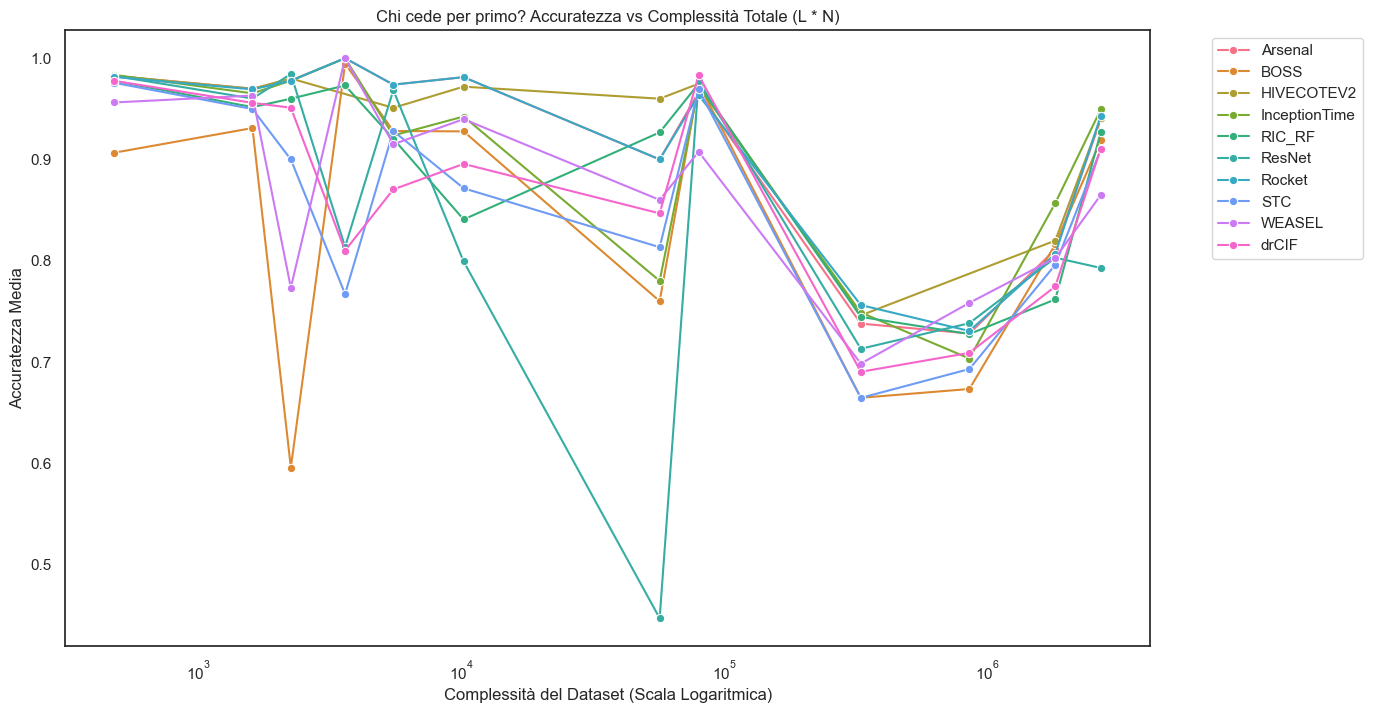

In [121]:
df_final['complexity'] = df_final['series_length'] * df_final['train_size']

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_final, x='complexity', y='accuracy_mean',
             hue='classifier_name', palette=algo_palette, marker='o')

plt.xscale('log') # Obbligatorio, la complessità esplode
plt.grid(False)
plt.title('Chi cede per primo? Accuratezza vs Complessità Totale (L * N)')
plt.xlabel('Complessità del Dataset (Scala Logaritmica)')
plt.ylabel('Accuratezza Media')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Grafico salvato come: confronto_rocket_arsenal.pdf


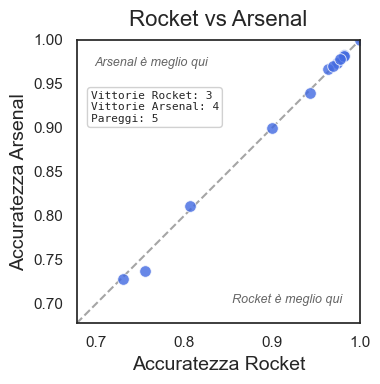

In [138]:
def plot_1v1(df, algo_x, algo_y, metric='accuracy_mean', size=(5, 5), filename=None):
    # 1. Prepariamo i dati
    pivot_df = df.pivot(index='dataset_name', columns='classifier_name', values=metric)

    # 2. Estraiamo i dati (dropna per dataset non comuni)
    pair_data = pivot_df[[algo_x, algo_y]].dropna()
    data_x = pair_data[algo_x]
    data_y = pair_data[algo_y]

    # 3. Creazione del plot con dimensione variabile
    fig, ax = plt.subplots(figsize=size)

    # Limiti assi fissati a 1.0
    min_val = min(data_x.min(), data_y.min()) - 0.05
    limit = [min_val, 1.0]

    # Linea diagonale
    ax.plot(limit, limit, ls="--", c=".3", alpha=0.5, zorder=1)

    # Scatter plot (riduco leggermente la dimensione dei punti 's' per il formato piccolo)
    sns.scatterplot(x=data_x, y=data_y, s=70, color='royalblue', edgecolor='w', alpha=0.8, zorder=2)

    # Calcolo statistiche
    wins_x = (data_x > data_y).sum()
    wins_y = (data_y > data_x).sum()
    ties = (data_x == data_y).sum()

    # Annotazioni (ridotte di font per il formato piccolo)
    ax.text(limit[0] + 0.02, limit[1] - 0.02, f"{algo_y} è meglio qui",
            fontsize=9, fontstyle='italic', color='.4', va='top', ha='left')
    ax.text(limit[1] - 0.02, limit[0] + 0.02, f"{algo_x} è meglio qui",
            fontsize=9, fontstyle='italic', color='.4', va='bottom', ha='right')

    # Riquadro riassuntivo
    stats_text = (f"Vittorie {algo_x}: {wins_x}\n"
                  f"Vittorie {algo_y}: {wins_y}\n"
                  f"Pareggi: {ties}")

    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='.8')
    ax.text(0.05, 0.82, stats_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', bbox=props, fontfamily='monospace')

    # Titoli e Label (ridotti per proporzione)
    ax.set_title(f'{algo_x} vs {algo_y}', fontsize=16, pad=10)
    ax.set_xlabel(f'Accuratezza {algo_x}', fontsize=14)
    ax.set_ylabel(f'Accuratezza {algo_y}', fontsize=14)

    ax.set_xlim(limit)
    ax.set_ylim(limit)
    ax.set_aspect('equal')
    plt.grid(False)

    plt.tight_layout()

    # 4. Salvataggio
    if filename:
        # Uso dpi=300 per avere un'alta qualità anche se il formato è piccolo
        plt.savefig(filename, bbox_inches='tight', dpi=300)
        print(f"Grafico salvato come: {filename}")

    plt.show()

# Esempio di utilizzo con salvataggio:
plot_1v1(df_final, 'Rocket', 'Arsenal', size=(4, 4), filename='confronto_rocket_arsenal.pdf')

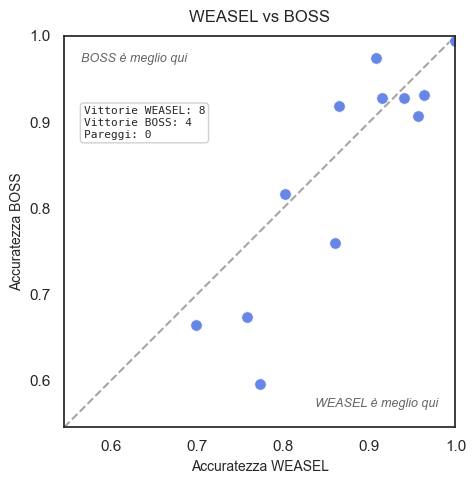

In [123]:
plot_1v1(df_final, 'WEASEL', 'BOSS')

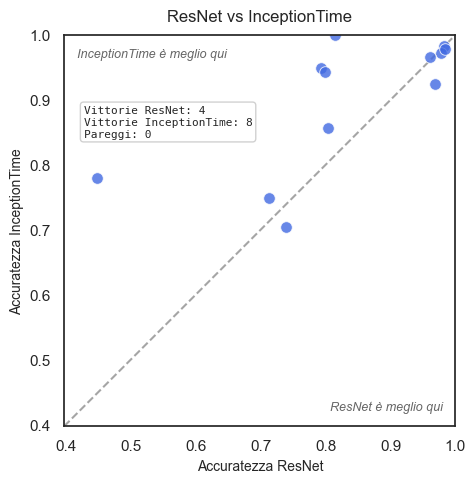

In [124]:
plot_1v1(df_final, 'ResNet', 'InceptionTime')

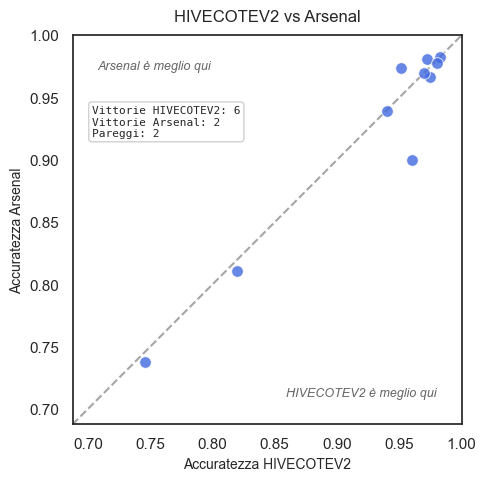

In [125]:
plot_1v1(df_final, 'HIVECOTEV2', 'Arsenal')

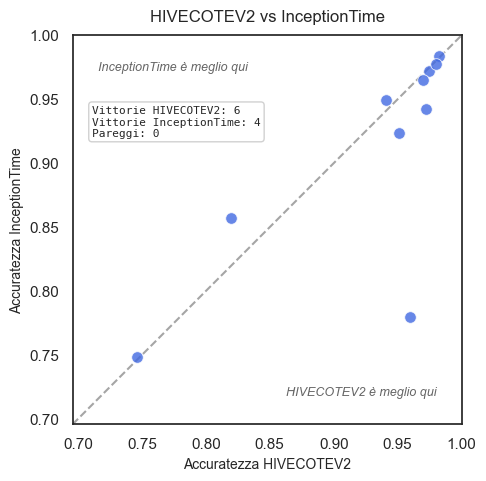

In [126]:
plot_1v1(df_final, 'HIVECOTEV2', 'InceptionTime')

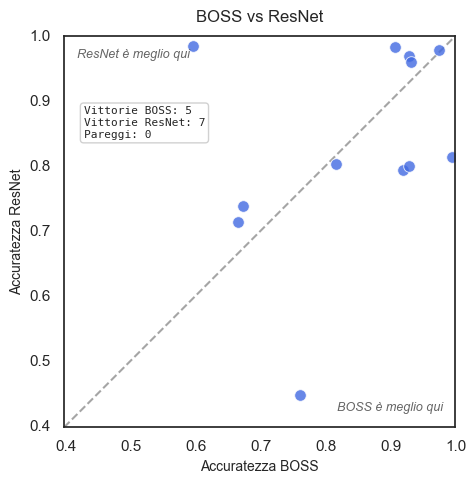

In [127]:
plot_1v1(df_final, 'BOSS', 'ResNet')

Grafico salvato come: confronto_HC2_Arsenal.pdf


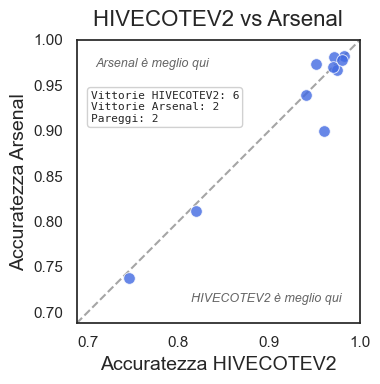

In [158]:
plot_1v1(df_final, 'HIVECOTEV2', 'Arsenal', size=(4, 4), filename='confronto_HC2_Arsenal.pdf')

Grafico salvato come: confronto_HC2_DrCIF.pdf


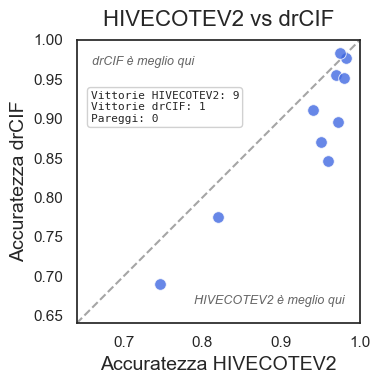

In [159]:
plot_1v1(df_final, 'HIVECOTEV2', 'drCIF', size=(4, 4), filename='confronto_HC2_DrCIF.pdf')

Grafico salvato come: confronto_HC2_STC.pdf


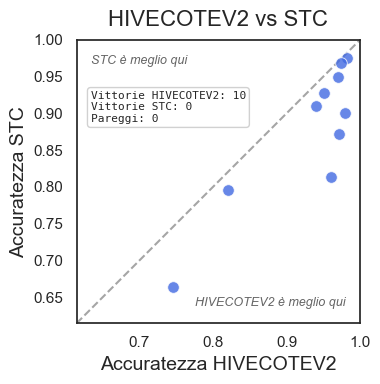

In [157]:
plot_1v1(df_final, 'HIVECOTEV2', 'STC', size=(4, 4), filename='confronto_HC2_STC.pdf')

In [153]:
print(df_final_avg)


  classifier_name  accuracy  total_time_seconds
0         Arsenal  0.914018          138.322106
1            BOSS  0.840925         6009.007975
2             HC2  0.929623        37384.567396
3   InceptionTime  0.900263         2584.703810
4          RIC_RF  0.890487         6022.404110
5          ResNet  0.831611         5506.628636
6          Rocket  0.915306           52.540286
7             STC  0.853145         7131.174047
8          WEASEL  0.869909           60.322647
9           drCIF  0.864577         9874.174068


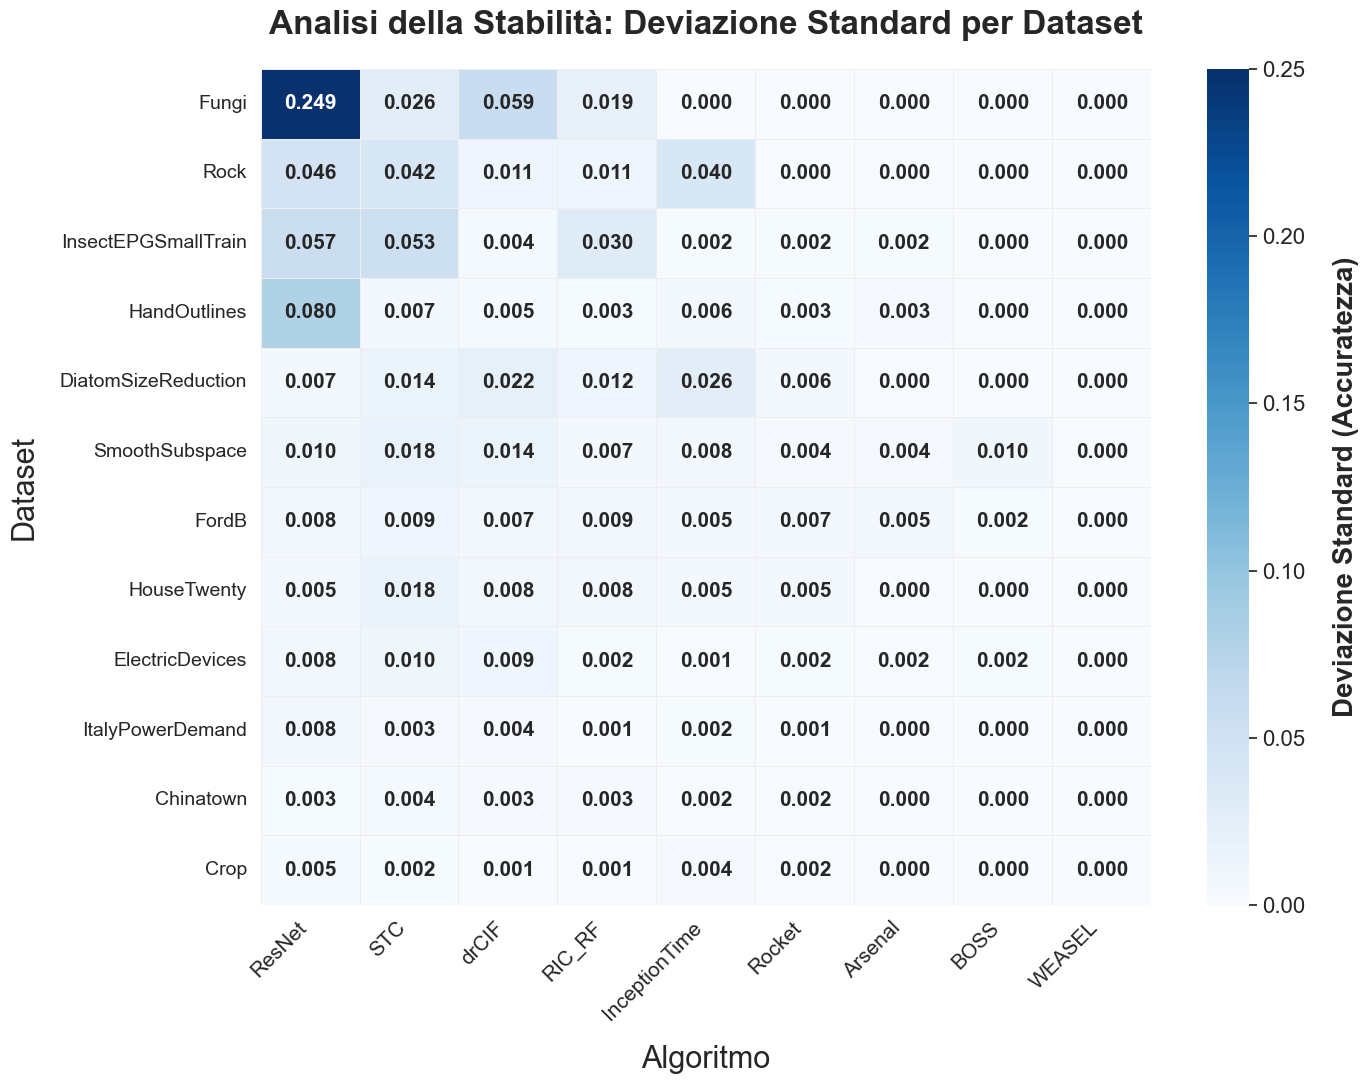

In [201]:
# 1. Reset totale
plt.rcParams.update(plt.rcParamsDefault)
sns.set_theme(style="white")

# 2. Prepariamo i dati
std_pivot = df_final.pivot(index='dataset_name', columns='classifier_name', values='accuracy_std')

# --- RIMOZIONE HIVECOTEV2 ---
if 'HIVECOTEV2' in std_pivot.columns:
    std_pivot = std_pivot.drop(columns=['HIVECOTEV2'])

# --- ORDINAMENTO DOPPIO (EFFETTO ANGOLO) ---

# A. Ordiniamo i DATASET (Righe) dalla più alta alla più bassa instabilità media
std_pivot['mean_rows'] = std_pivot.mean(axis=1)
std_pivot = std_pivot.sort_values('mean_rows', ascending=False).drop(columns='mean_rows')

# B. Ordiniamo gli ALGORITMI (Colonne) dal più alto al più basso instabilità media
# Calcoliamo la media per colonna, la ordiniamo e riorganizziamo il pivot
mean_cols = std_pivot.mean(axis=0).sort_values(ascending=False)
std_pivot = std_pivot[mean_cols.index]

# 3. Creazione figura
plt.figure(figsize=(14, 11))

# --- GENERAZIONE HEATMAP ---
ax = sns.heatmap(
    std_pivot,
    annot=True,
    fmt='.3f',
    cmap='Blues',
    vmin=0,
    vmax=0.25,
    linewidths=0.5,
    linecolor='#eeeeee',
    annot_kws={"size": 15, "fontweight": 'bold'}
)

# 4. PERSONALIZZAZIONE COLORBAR (LA SCALA)
cbar = ax.collections[0].colorbar
cbar.set_label('Deviazione Standard (Accuratezza)', size=20, weight='bold', labelpad=20)
cbar.ax.tick_params(labelsize=16)

# 5. Fontsize per la Tesi (Titoli e Assi)
plt.title('Analisi della Stabilità: Deviazione Standard per Dataset', fontsize=24, pad=25, fontweight='bold')
plt.ylabel('Dataset', fontsize=22, labelpad=15)
plt.xlabel('Algoritmo', fontsize=22, labelpad=15)

# Tick degli assi
plt.xticks(fontsize=15, rotation=45, ha='right')
plt.yticks(fontsize=14)

# 6. Salvataggio
plt.tight_layout()
plt.savefig('heatmap_stabilita_blues_ordinata.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [203]:
# 1. Creiamo il pivot della deviazione standard
std_pivot = df_final.pivot(index='dataset_name', columns='classifier_name', values='accuracy_std')

# 2. Definiamo l'ordine esatto degli algoritmi che hai richiesto
# Nota: Ho usato HiveCote2 (o HIVECOTEV2) a seconda di come è scritto nel tuo DF
col_order = ['Arsenal', 'BOSS', 'HIVECOTEV2', 'InceptionTime', 'RIC_RF', 'ResNet', 'Rocket', 'STC', 'WEASEL', 'drCIF']

# Filtriamo solo le colonne esistenti (per evitare errori se HiveCote è già stato rimosso o rinominato)
existing_cols = [c for c in col_order if c in std_pivot.columns]
std_output = std_pivot[existing_cols]

# 3. Ordiniamo i dataset alfabeticamente per trovarli subito nella tua tabella LaTeX
std_output = std_output.sort_index()

# 4. Stampiamo i dati pronti per il copia-incolla
print("--- COPIA I DATI DA QUI ---")
print(std_output.to_string(float_format=lambda x: "{:.3f}".format(x) if not pd.isna(x) else "-"))

--- COPIA I DATI DA QUI ---
classifier_name      Arsenal  BOSS  HIVECOTEV2  InceptionTime  RIC_RF  ResNet  Rocket   STC  WEASEL  drCIF
dataset_name                                                                                              
Chinatown              0.000 0.000         NaN          0.002   0.003   0.003   0.002 0.004   0.000  0.003
Crop                   0.000 0.000         NaN          0.004   0.001   0.005   0.002 0.002   0.000  0.001
DiatomSizeReduction    0.000 0.000         NaN          0.026   0.012   0.007   0.006 0.014   0.000  0.022
ElectricDevices        0.002 0.002         NaN          0.001   0.002   0.008   0.002 0.010   0.000  0.009
FordB                  0.005 0.002         NaN          0.005   0.009   0.008   0.007 0.009   0.000  0.007
Fungi                  0.000 0.000         NaN          0.000   0.019   0.249   0.000 0.026   0.000  0.059
HandOutlines           0.003 0.000         NaN          0.006   0.003   0.080   0.003 0.007   0.000  0.005
HouseTwen

In [204]:
# 1. Filtriamo il dataframe per i due algoritmi richiesti
target_algos = ['HIVECOTEV2', 'Rocket']
df_filtered = df_final[df_final['classifier_name'].isin(target_algos)]

# 2. Calcoliamo la media complessiva (su tutti i dataset)
mean_accuracies = df_filtered.groupby('classifier_name')['accuracy_mean'].mean()

print("--- Accuratezza Media Globale ---")
for algo, val in mean_accuracies.items():
    print(f"{algo}: {val:.4f}")

# 3. Se vuoi vedere il dettaglio per ogni dataset (utile per la tabella)
pivot_detail = df_filtered.pivot(index='dataset_name', columns='classifier_name', values='accuracy_mean')
print("\n--- Dettaglio per Dataset ---")
print(pivot_detail.to_string())

--- Accuratezza Media Globale ---
HIVECOTEV2: 0.9296
Rocket: 0.9153

--- Dettaglio per Dataset ---
classifier_name      HIVECOTEV2  Rocket
dataset_name                           
Chinatown                0.9825  0.9815
Crop                     0.7459  0.7561
DiatomSizeReduction      0.9510  0.9739
ElectricDevices             NaN  0.7305
FordB                    0.8198  0.8066
Fungi                       NaN  1.0000
HandOutlines             0.9405  0.9432
HouseTwenty              0.9748  0.9636
InsectEPGSmallTrain      0.9719  0.9813
ItalyPowerDemand         0.9699  0.9692
Rock                     0.9600  0.9000
SmoothSubspace           0.9800  0.9778


In [205]:
# Filtriamo i dati per i due algoritmi
target_algos = ['HIVECOTEV2', 'Rocket']
df_subset = df_final[df_final['classifier_name'].isin(target_algos)]

# Calcolo della media totale (media della colonna accuracy_mean)
media_totale = df_subset.groupby('classifier_name')['accuracy_mean'].mean()

print("--- ACCURATEZZA MEDIA TOTALE ---")
print(f"HIVECOTEV2: {media_totale['HIVECOTEV2']:.4f}")
print(f"Rocket:     {media_totale['Rocket']:.4f}")

# Opzionale: Conteggio dei dataset considerati (per correttezza scientifica)
count_datasets = df_subset.groupby('classifier_name')['accuracy_mean'].count()
print("\n--- DATASET CONSIDERATI ---")
print(f"HIVECOTEV2: {count_datasets['HIVECOTEV2']} dataset")
print(f"Rocket:     {count_datasets['Rocket']} dataset")

--- ACCURATEZZA MEDIA TOTALE ---
HIVECOTEV2: 0.9296
Rocket:     0.9153

--- DATASET CONSIDERATI ---
HIVECOTEV2: 10 dataset
Rocket:     12 dataset


In [206]:
# 1. Calcoliamo la media dell'accuratezza per ogni algoritmo
# Groupby aggrega per nome del classificatore, poi prendiamo la colonna della media
report_finale = df_final.groupby('classifier_name')['accuracy_mean'].agg(['mean', 'count'])

# 2. Ordiniamo dal migliore al peggiore (media decrescente)
report_finale = report_finale.sort_values(by='mean', ascending=False)

# 3. Stampa formattata
print(f"{'Algoritmo':<20} | {'Media Totale':<15} | {'Dataset Testati'}")
print("-" * 55)

for algo, row in report_finale.iterrows():
    print(f"{algo:<20} | {row['mean']:<15.4f} | {int(row['count'])}")

Algoritmo            | Media Totale    | Dataset Testati
-------------------------------------------------------
HIVECOTEV2           | 0.9296          | 10
Rocket               | 0.9153          | 12
Arsenal              | 0.9140          | 12
InceptionTime        | 0.9003          | 12
RIC_RF               | 0.8905          | 12
WEASEL               | 0.8699          | 12
drCIF                | 0.8646          | 12
STC                  | 0.8531          | 12
BOSS                 | 0.8409          | 12
ResNet               | 0.8316          | 12
